In [32]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
term_dep=pd.read_csv("bank-full.csv")

## Understanding the data

In [35]:
term_dep.shape

(45211, 17)

The data provided has 45211 rows and 17 columns including the target variable

In [37]:
term_dep.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
age          45211 non-null int64
job          45211 non-null object
marital      45211 non-null object
education    45211 non-null object
default      45211 non-null object
balance      45211 non-null int64
housing      45211 non-null object
loan         45211 non-null object
contact      45211 non-null object
day          45211 non-null int64
month        45211 non-null object
duration     45211 non-null int64
campaign     45211 non-null int64
pdays        45211 non-null int64
previous     45211 non-null int64
poutcome     45211 non-null object
Target       45211 non-null object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


Hence, there are no null or NaN values in the data set. Further: age, balance, duration (duration of last contact), campaign (number of contacts performed during this campaign ), previous (number of contacts performed before this campaign) are all integer values. Age and balance maybe a continuous distribution. However, the others may have to be discrete

Categorical variables include job (Type of job), marital (Marital status), Education(last education sought), default (has the customer defaulted?), housing (does he have a housing loan?), loan (Has he taken a personal loan?), contact (mode of contact with the customer),  month (Month when customer was last contacted), poutcome (Outcome of the previous campaign) and target (whether the customer enrolled in the campaign

Further if 'day' implies the day of month when the contact was made, then this may have to be converted to a categorical variable

In [38]:
term_dep.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Skew: Age, day and campaign have means that are quite similar to the 50%ile value. 
    However, the mean of balance and duration is significantly higher than the 50% mean indicating a positive skew
Similarly, balance, day and campaign also have their Q3-Q2 significantly greater than their Q2-Q1 which implies positive skewness

Pdays and previous have some curious values across the 25%, 50% and 75% quartiles. 
Previous has all zeroes indicating that there may be a large number of 0 in the dataset which may need to be checked or that almost 75% of all the targets have never been contacted. 
Similarly, pdays has negative values. Since pdays refers to the number of days that passed by after the client was last contacted from a previous campaign, this is not possible and needs to be further investigated


Outliers: There seem to be a significant number of outliers across all the columns since the maximum value is significantly higher than the 75% values by almost double or more. Hence this will be need to looked into and normalied

In [7]:
a=term_dep.loc[term_dep['previous'] == 0, 'previous'].count() #Count number of records where previous is 0
b=term_dep.loc[term_dep['previous'] == 0, 'pdays'].sum()    #sum value of pdays where previous is 0
a,b

(36954, -36954)

Hence, based on the analysis, we come to the conclusion that pdays is given the value of -1 if the customer was not contacted from a previous campaign.To prevent any issue during calculations, we will change the value to 0
Further, the uncontacted customers constitute 81% of all subscribers. Hence, to assess the effectiveness of the pdays and previous columns, we might have to split the columns into 0 and greater than 0 prior to analysis

In [4]:
term_dep.loc[term_dep['pdays'] == -1, 'pdays'] = 0

In [9]:
term_dep['pdays'].describe() #Checking accuracy of replacement

count    45211.000000
mean        41.015195
std         99.792615
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        871.000000
Name: pdays, dtype: float64

'Day' does not provide any mathematical value rather than the last date of the contact. Hence, we may convert this to an object

## Univariate Analysis

In [59]:
quantparams = term_dep.copy()
quantparams = quantparams.select_dtypes(exclude=['object'])
quantparams['Target'] = term_dep['Target']
qualparams = term_dep.copy()
qualparams = qualparams.select_dtypes(exclude=['int64'])




In [13]:
for i in range(len(qualparams.columns)):
    qualparams[qualparams.columns[i]]
    j = qualparams[qualparams.columns[i]].value_counts()
    try:
        j['unknown']
        k = j['unknown']
        l =  k * 100 / qualparams[qualparams.columns[i]].count()
        print('Number of unknown values in ',qualparams.columns[i], 'is: ',k)
        print(l ,'% of all details in ',qualparams.columns[i], 'are unknown')
    except:
        print('No unknown values in ',qualparams.columns[i])

Number of unknown values in  job is:  288
0.6370131162770122 % of all details in  job are unknown
No unknown values in  marital
Number of unknown values in  education is:  1857
4.1074074893278185 % of all details in  education are unknown
No unknown values in  default
No unknown values in  housing
No unknown values in  loan
Number of unknown values in  contact is:  13020
28.798301298356595 % of all details in  contact are unknown
No unknown values in  month
Number of unknown values in  poutcome is:  36959
81.74780473778505 % of all details in  poutcome are unknown
No unknown values in  Target


There is a significant number of unknown variables in 'contact' and 'poutcome'. Hence, we will need to deal with this while finalizing the data transformation prior to analysis

### Uninvariate analysis to assess shape of the distribution of the quantitative parameters

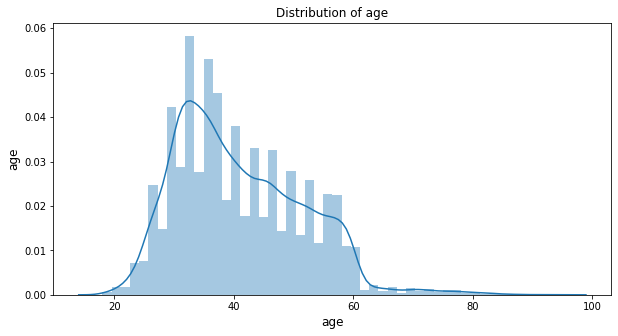

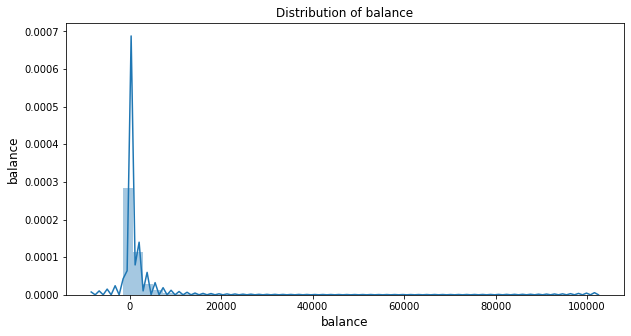

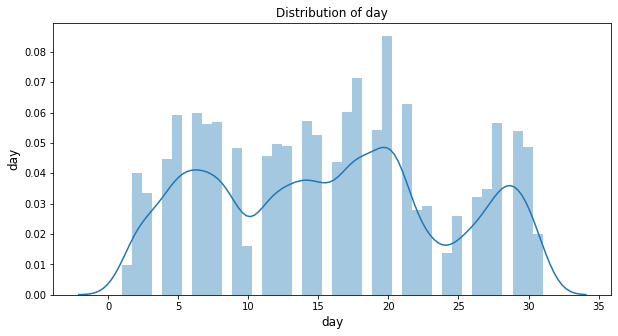

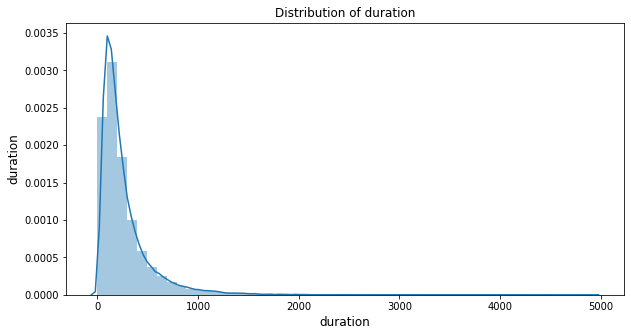

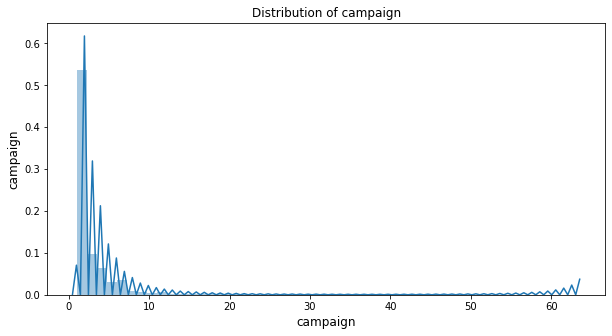

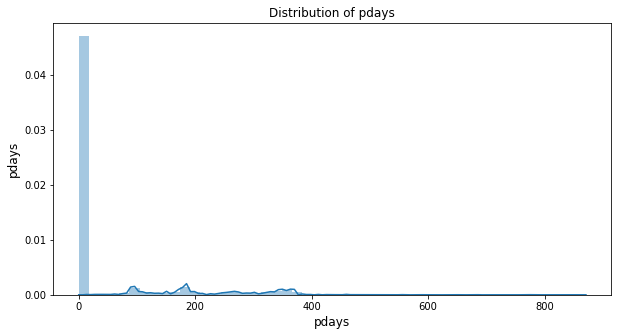

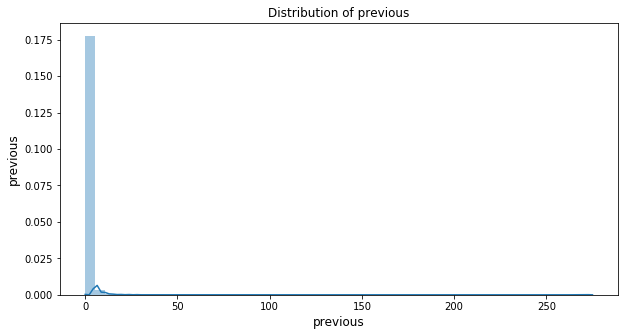

In [14]:
for i in range(len(quantparams.columns)-1):
    g=sns.distplot(quantparams[[quantparams.columns[i]]])
    g.figure.set_size_inches(10,5)
    title1='Distribution of '
    title1=title1+quantparams.columns[i]
    plt.title(title1)
    plt.ylabel(quantparams.columns[i], fontsize=12)
    plt.xlabel(quantparams.columns[i], fontsize=12)
    plt.show()

Key observations: Age seems to have multiple Gaussians in the data resulting in varying peaks with most of the base between 25 and 60 years. Multiple Gaussians could be addressed by binning the age groups to see if there is better correlation. Further, we can truncate age to 60 if required.
Balance seems to relatively normal but with outliers up to 100000 with a sharp peak at 0. This may imply that we need to better classify these outliers.
Of the 36,959 records which have poutcome as Unknown, 36,954 records refer to cases where the target was not contacted previously for any campaign. Hence, it will make sense to perform separate bi-variate and uni-variate analysis where the poutcome is not Unknown

As expected, all parameters have heavy positive skews and very long set of outliers in each of the data

Analysis of data after ignoring all unknown previous outcomes

In [15]:
known_outcome=term_dep[term_dep['poutcome'] != 'unknown'].copy()
known_outcome.shape

(8252, 17)

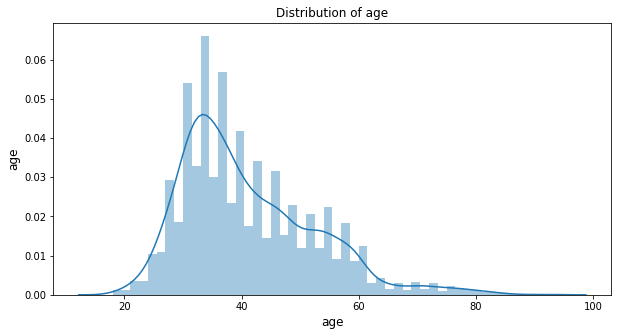

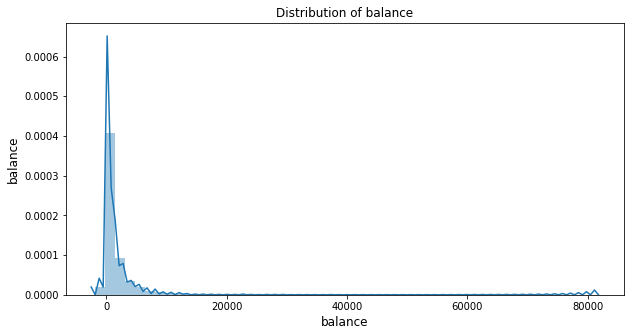

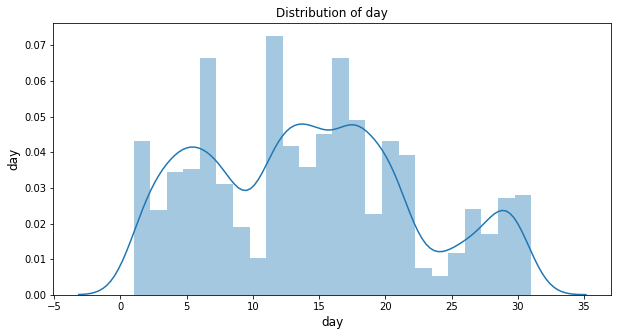

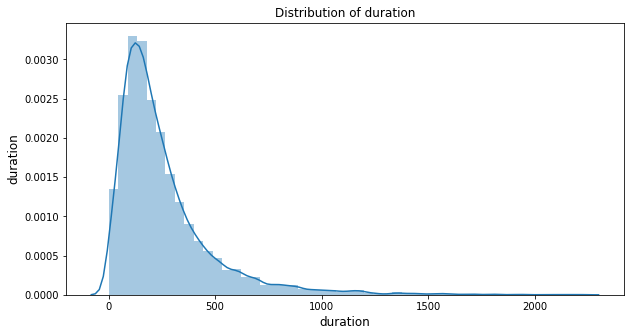

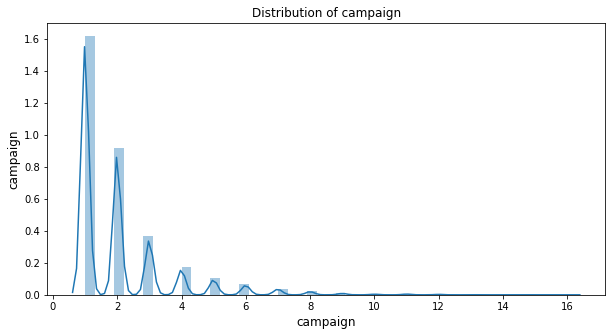

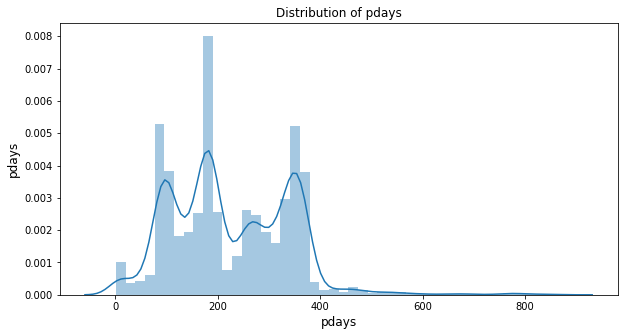

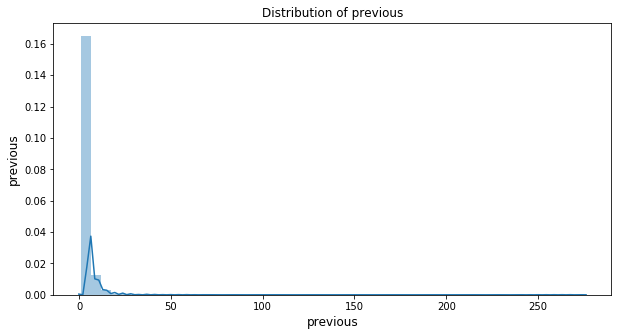

In [16]:
for i in range(len(known_outcome.columns)-1):
    if(known_outcome[known_outcome.columns[i]].dtype == 'int64'):
        g=sns.distplot(known_outcome[[known_outcome.columns[i]]])
        g.figure.set_size_inches(10,5)
        title1='Distribution of '
        title1=title1+known_outcome.columns[i]
        plt.title(title1)
        plt.ylabel(known_outcome.columns[i], fontsize=12)
        plt.xlabel(known_outcome.columns[i], fontsize=12)
        plt.show()

### Checking if the Target variable shows any kind of separation for each of the quantitative parameters

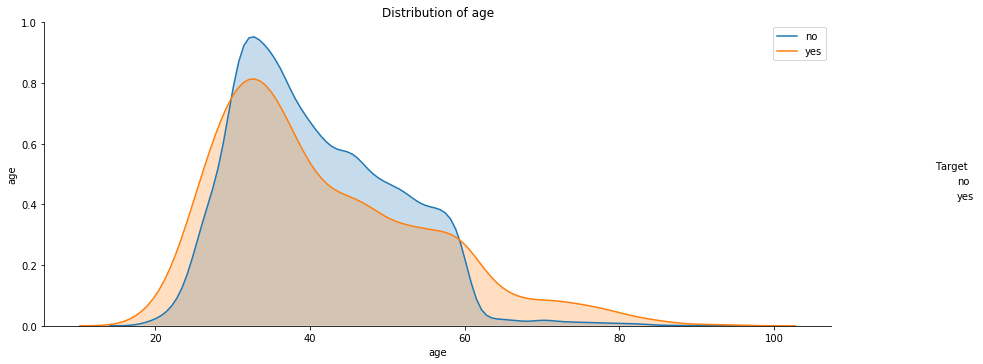

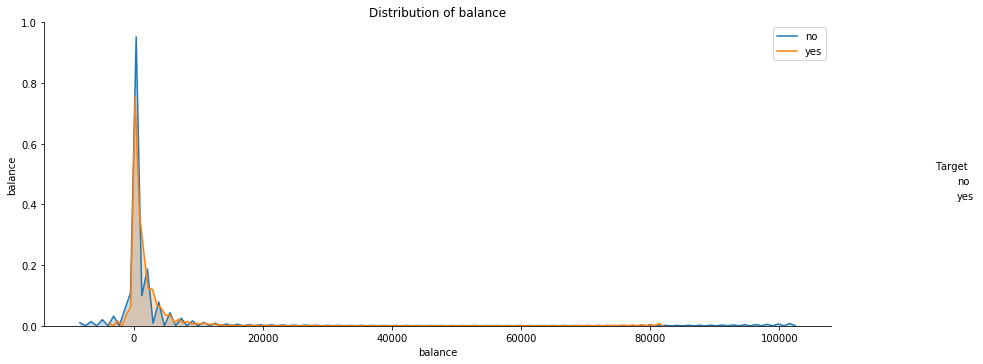

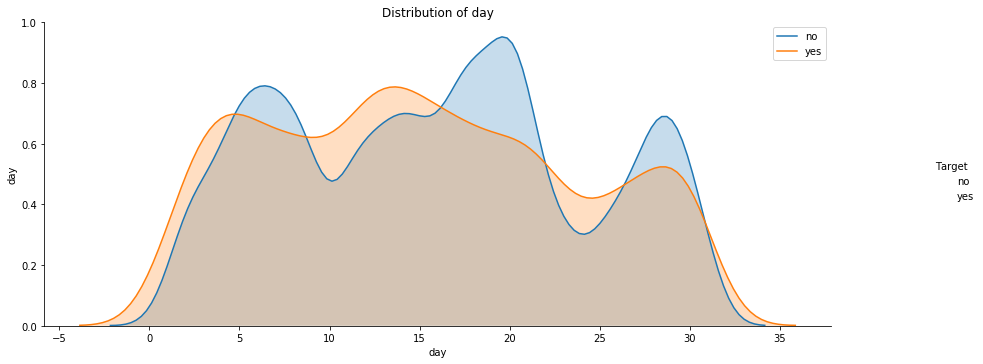

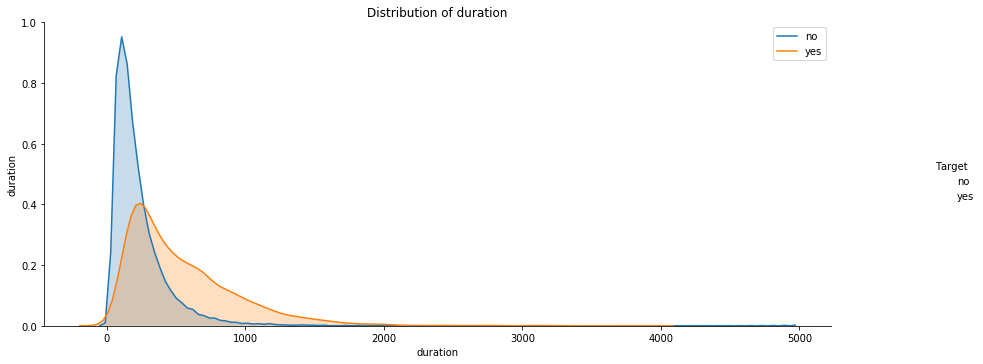

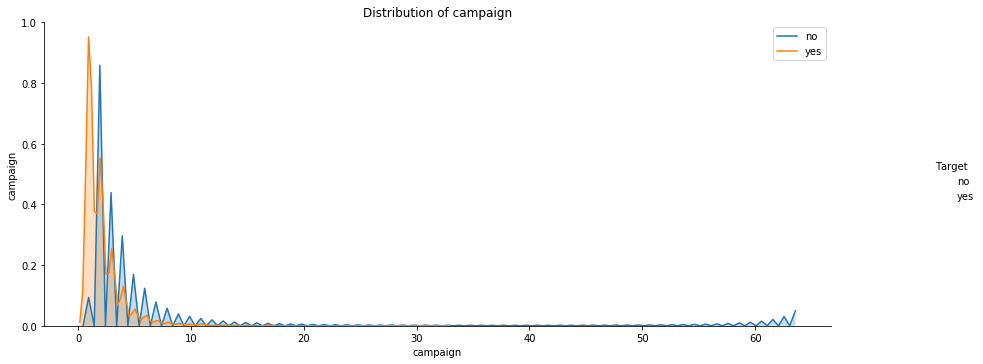

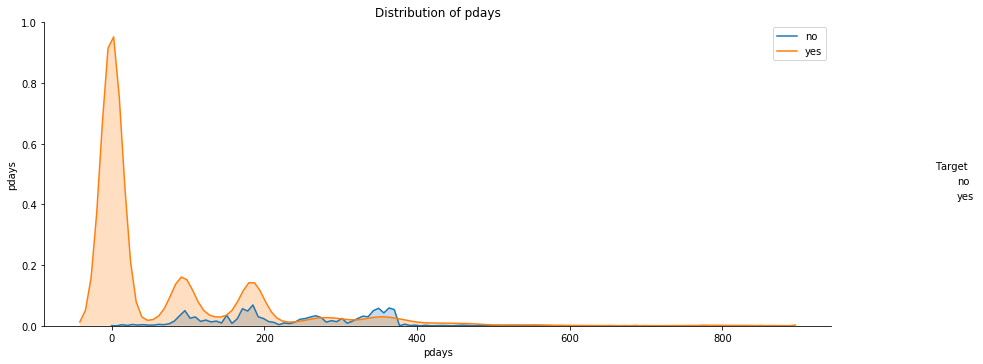

In [17]:
for i in range(0,len(quantparams.columns)-2,1):
    g=sns.pairplot(quantparams[[quantparams.columns[i], 'Target']], hue='Target', height=5)
    g.fig.set_size_inches(15,5)
    title1='Distribution of '
    title1=title1+quantparams.columns[i]
    plt.title(title1)
    plt.ylabel(quantparams.columns[i], fontsize=12)
    plt.xlabel(quantparams.columns[i], fontsize=12)
    plt.legend()
    plt.show()

There is quite a bit of overlap between the target values across most of the quantitive parameters indicating a weak correlation between the Target variable and others. We see the most separation between effective target and ineffective targetting in pdays primarily where the large peak of 0 pdays which we had originally converted to imply that the customer was not contacted. Hence, we will perform this again without pdays=0

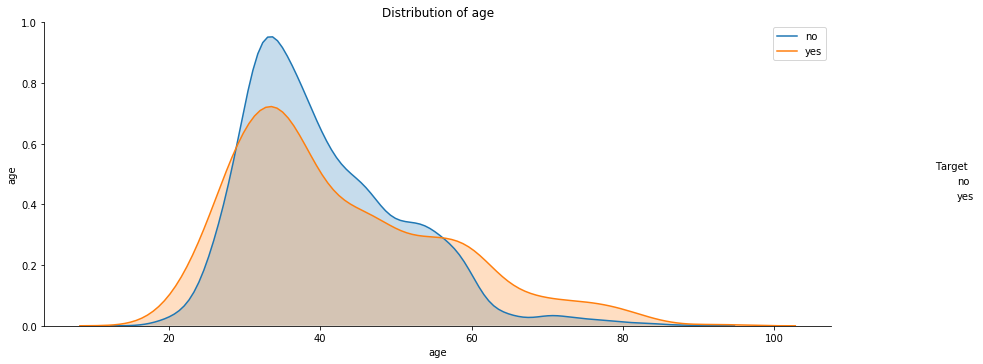

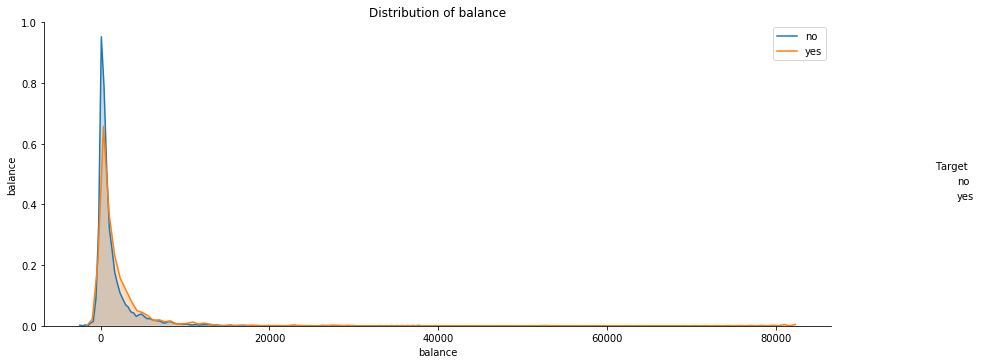

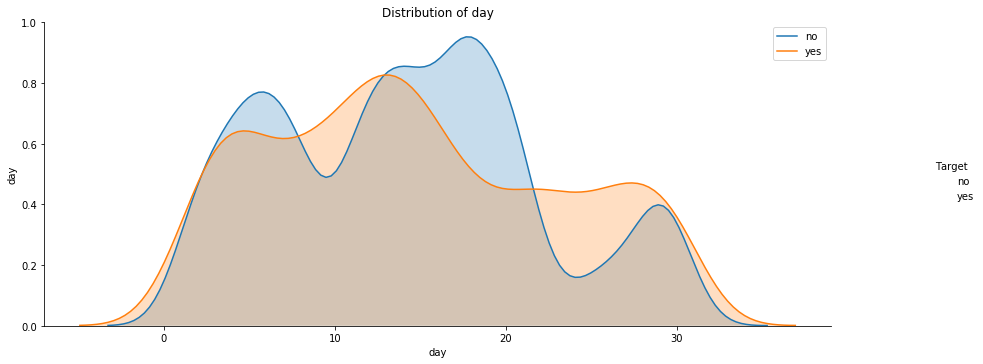

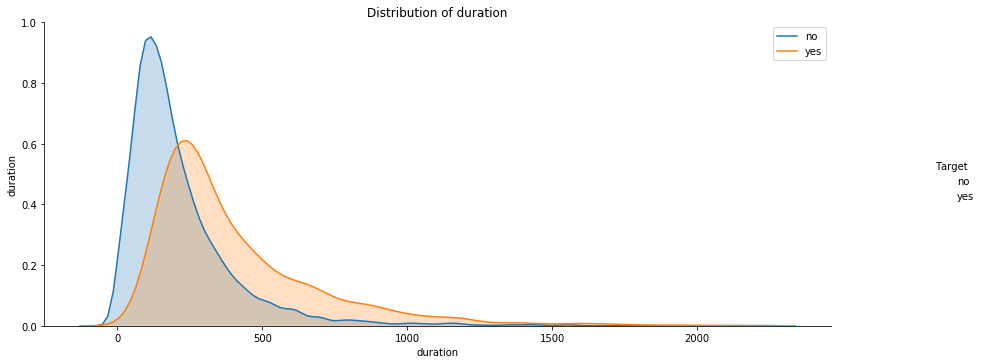

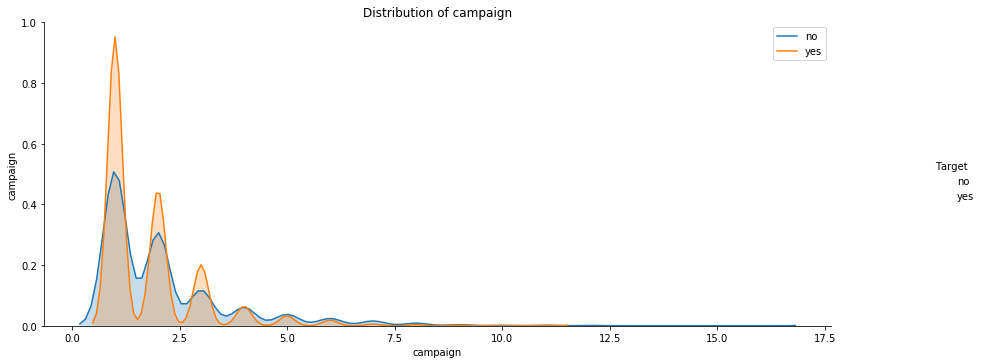

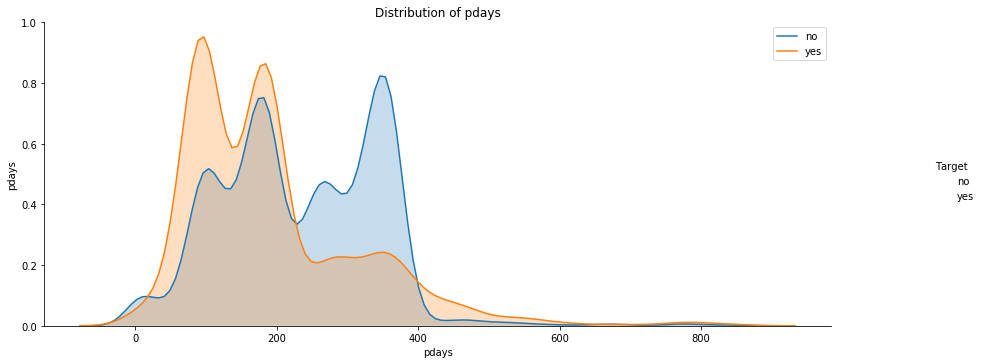

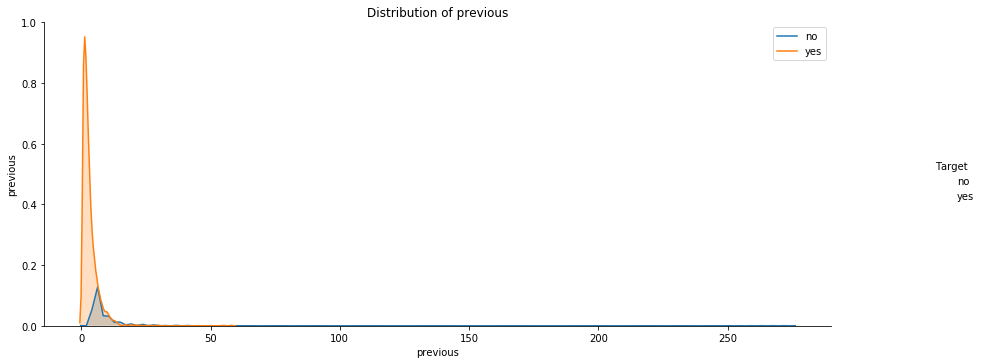

In [18]:
for i in range(0,len(known_outcome.columns)-2,1):
    if(known_outcome[known_outcome.columns[i]].dtype == 'int64'):
        g=sns.pairplot(known_outcome[[known_outcome.columns[i], 'Target']], hue='Target', height=5)
        #g=sns.pairplot(quantparams[[quantparams.columns[i], 'Target']], hue=quantparams['Target'])  #
        g.fig.set_size_inches(15,5)
        title1='Distribution of '
        title1=title1+known_outcome.columns[i]
        plt.title(title1)
        plt.ylabel(known_outcome.columns[i], fontsize=12)
        plt.xlabel(known_outcome.columns[i], fontsize=12)
        plt.legend()
        plt.show()

Target provides only one additional Gaussian in the case of pdays. In all other dimensions, it is proportionately distributed
Furthermore, all the quantitative parameters indicate significant outliers across their distribution. We will now identify these outliers as well as assess how many of them are beyond the 75th percentile

Similarly, the outliers for balance shows more effective targets than not while previous parameters show more ineffective targets in the outlier. This implies that as balance increases the prospects are more responsive to campaigns 

### Uni-variate analysis to review outlier presence using box plots for numeric parameters

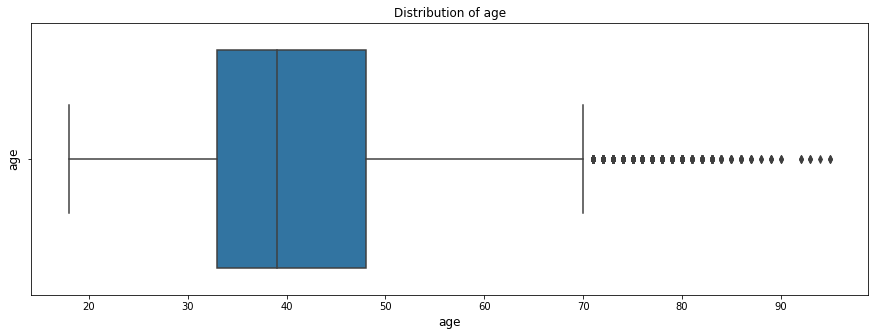

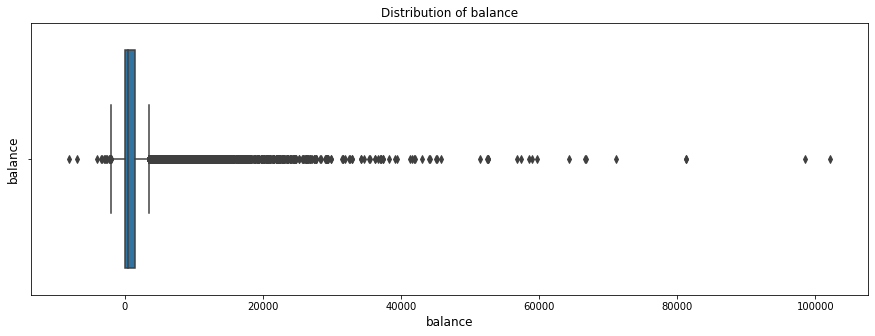

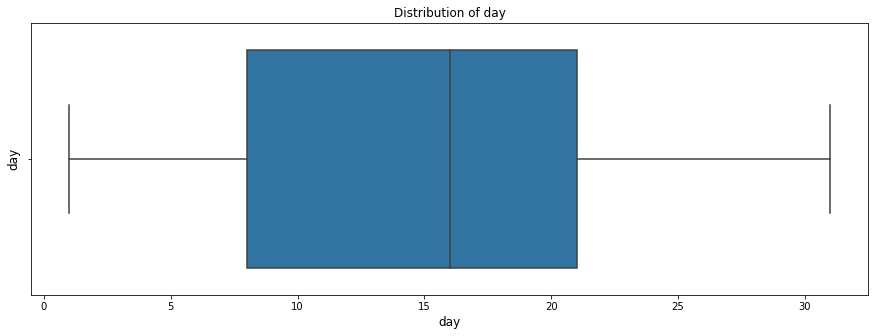

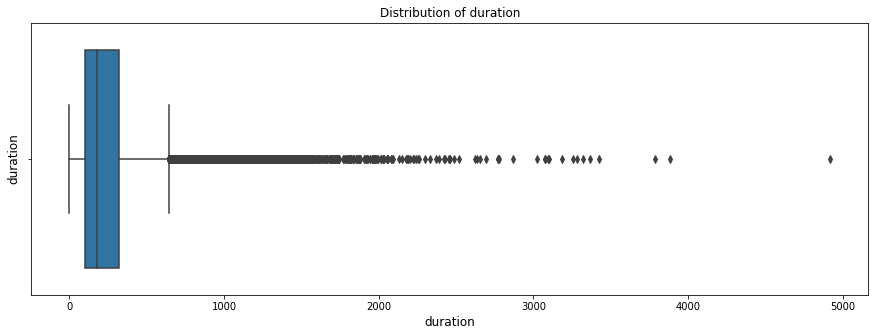

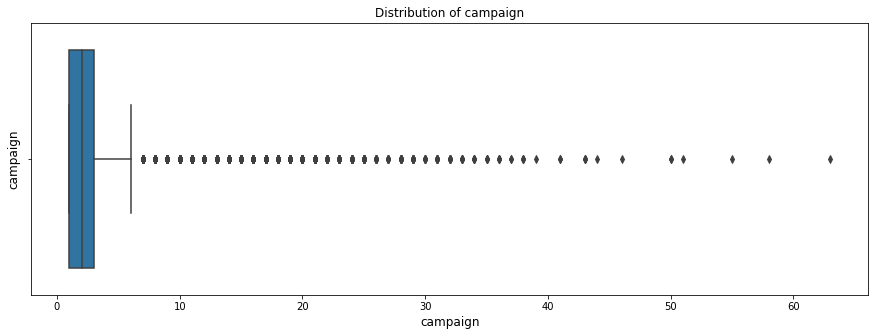

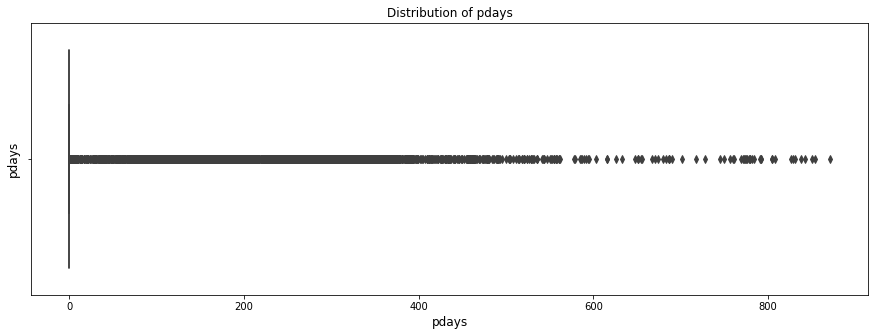

In [19]:
for i in range(0,len(quantparams.columns)-2,1):
    g=sns.boxplot(quantparams[[quantparams.columns[i]]], hue=quantparams['Target'])
    #g=sns.pairplot(quantparams[[quantparams.columns[i], 'Target']], hue=quantparams['Target'])  #
    g.figure.set_size_inches(15,5)
    title1='Distribution of '
    title1=title1+quantparams.columns[i]
    plt.title(title1)
    plt.ylabel(quantparams.columns[i], fontsize=12)
    plt.xlabel(quantparams.columns[i], fontsize=12)
    plt.show()

There are a large number of outliers for all the boxplots and hence, we will have to explore binning these variables while doing our bi-variate analysis

### Uni-variate analysis to assess distribution of categorical variables

In [20]:
values_bar=qualparams[qualparams.columns[1]].value_counts()
values_bar_per=values_bar/qualparams[qualparams.columns[1]].count()
values_bar_per

married     0.601933
single      0.282896
divorced    0.115171
Name: marital, dtype: float64

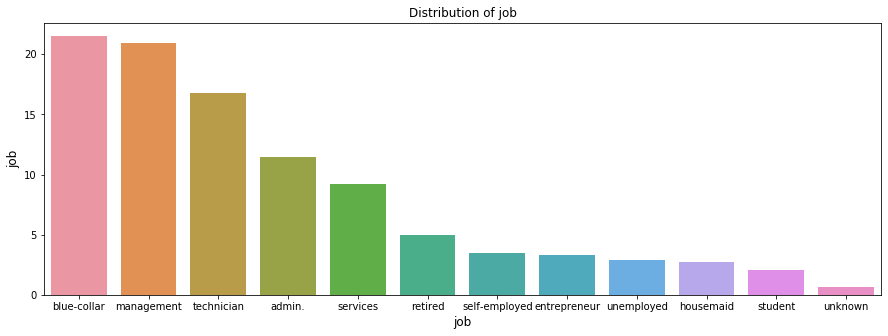

blue-collar      21.525735
management       20.919688
technician       16.803433
admin.           11.437482
services          9.188029
retired           5.007631
self-employed     3.492513
entrepreneur      3.289023
unemployed        2.882042
housemaid         2.742695
student           2.074716
unknown           0.637013
Name: job, dtype: float64


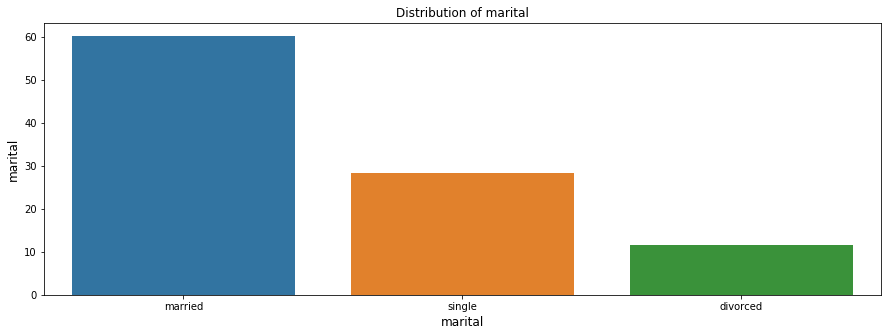

married     60.193316
single      28.289576
divorced    11.517109
Name: marital, dtype: float64


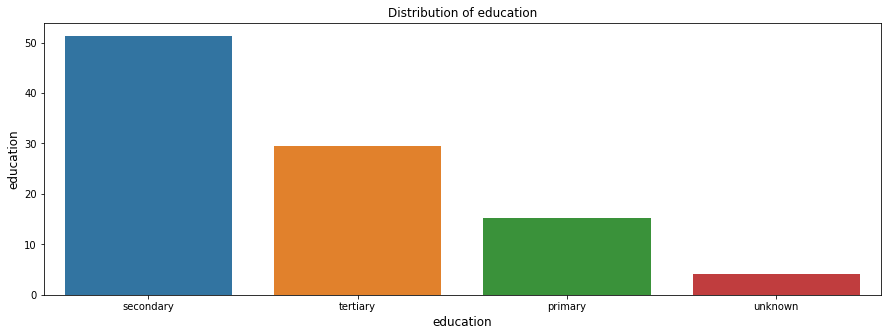

secondary    51.319369
tertiary     29.419831
primary      15.153392
unknown       4.107407
Name: education, dtype: float64


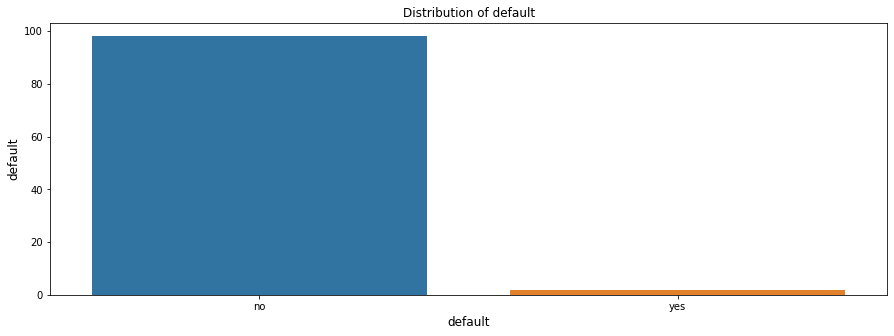

no     98.197341
yes     1.802659
Name: default, dtype: float64


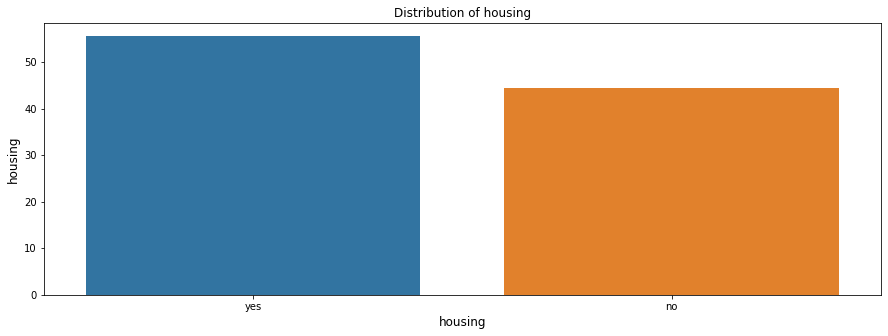

yes    55.583818
no     44.416182
Name: housing, dtype: float64


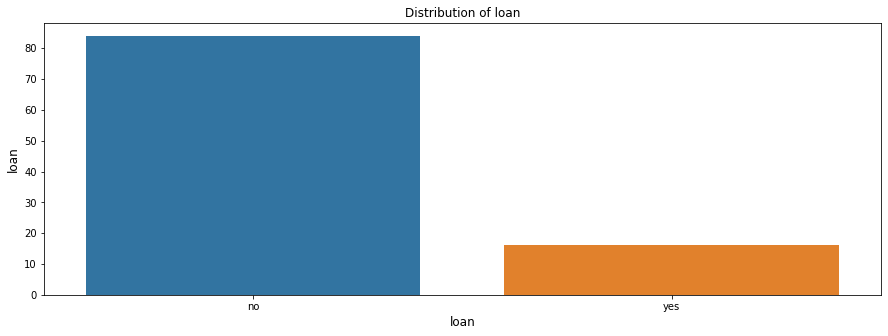

no     83.977351
yes    16.022649
Name: loan, dtype: float64


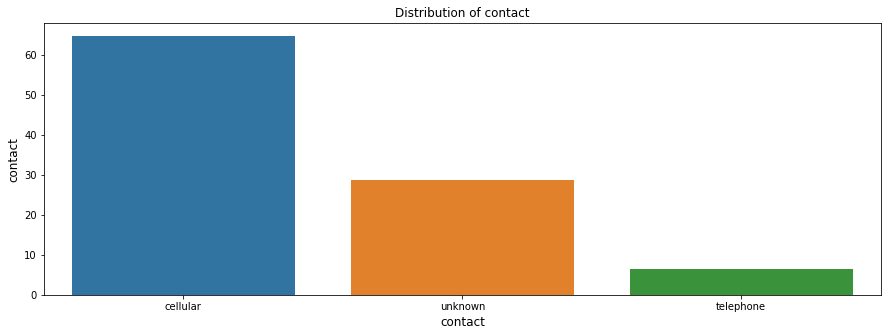

cellular     64.774059
unknown      28.798301
telephone     6.427639
Name: contact, dtype: float64


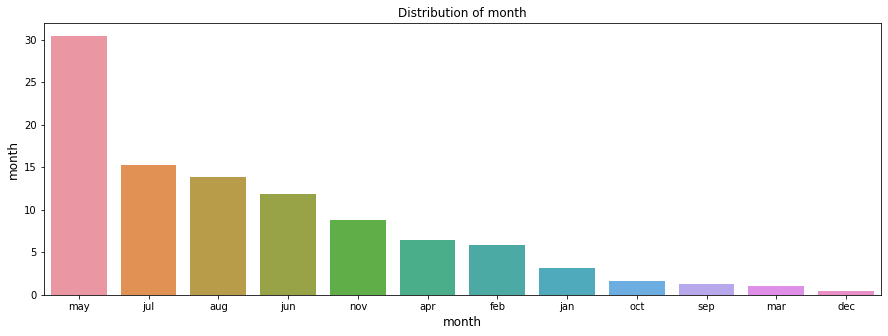

may    30.448342
jul    15.250713
aug    13.817434
jun    11.813497
nov     8.781049
apr     6.485147
feb     5.859194
jan     3.103227
oct     1.632346
sep     1.280662
mar     1.055053
dec     0.473336
Name: month, dtype: float64


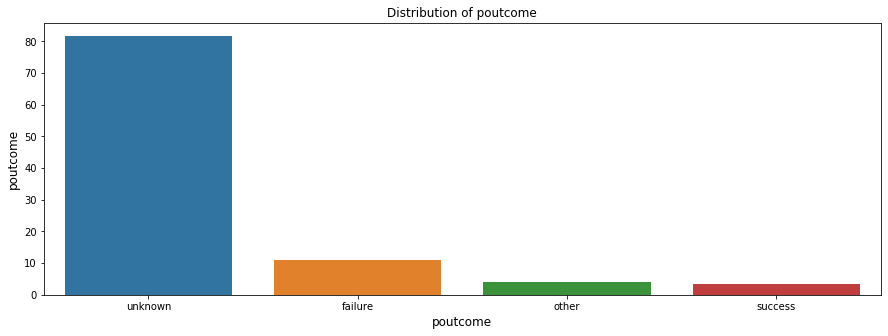

unknown    81.747805
failure    10.840282
other       4.069806
success     3.342107
Name: poutcome, dtype: float64


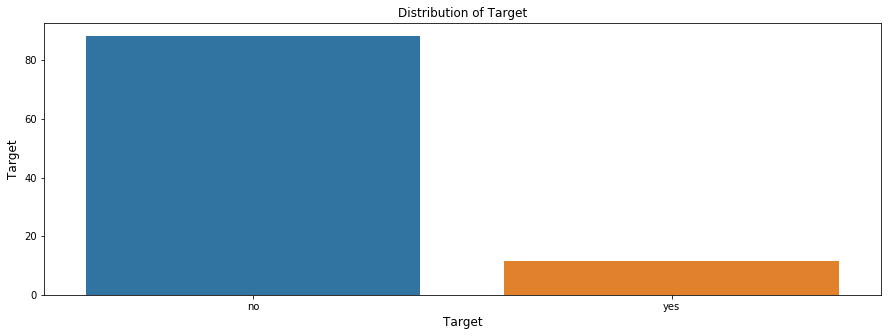

no     88.30152
yes    11.69848
Name: Target, dtype: float64


In [21]:
for i in range(0,len(qualparams.columns),1):
    values_bar=qualparams[qualparams.columns[i]].value_counts()
    values_bar_per=values_bar*100/qualparams[qualparams.columns[i]].count()
    g=sns.barplot(values_bar_per.index, values_bar_per.values)
    g.figure.set_size_inches(15,5)
    title1='Distribution of '
    title1=title1+qualparams.columns[i]
    plt.title(title1)
    plt.ylabel(qualparams.columns[i], fontsize=12)
    plt.xlabel(qualparams.columns[i], fontsize=12)
    plt.show()
    print(values_bar_per)

Key observations: Most of the qualitative parameters are distributed in a pattern that allows as-is inclusion in the model. This is with the exception of default which are extremely biased towards non-defaulters with 98% of all targets in that category. We will have to see how to deal with the same in the final data cleansing.
The trend in the days parameter is not clear. It seems to show some kind of weekly cycle. Hence, instead of showing days, if we had the days' name, it might be clearer.
Not entirely sure whether the month parameter might have an impact. We will use it for the bi-variate analysis to check applicability of the same.

## Bi-variate Analyis

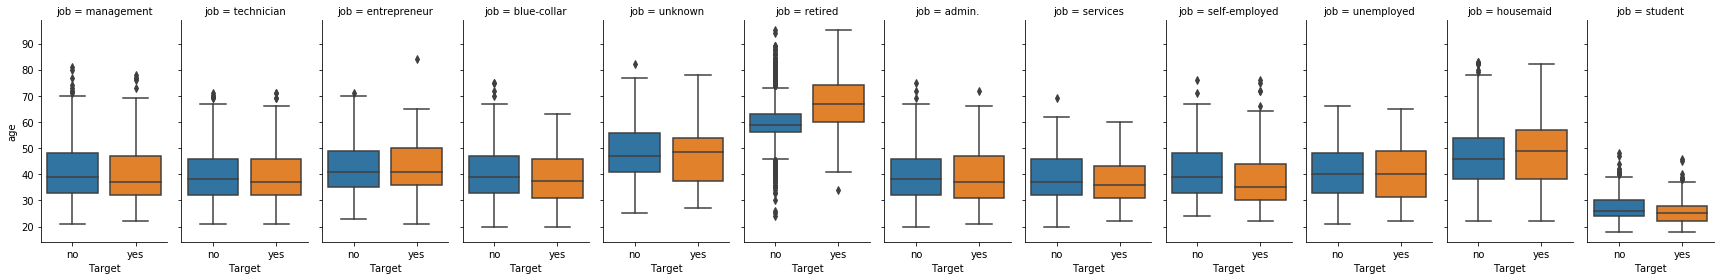

In [24]:
sns.catplot(x='Target', y='age', col='job', data=term_dep, kind='box', height=4, aspect=0.5);

Older retired prospects (60 - 70 years) seem to be more responsive to the campaigns as well as younger self-employed personnel (younger than 30) and younger students (<25 years). Overall, more entrepreneurs, retired, admin, unemployed and housemaids tend to subscribe

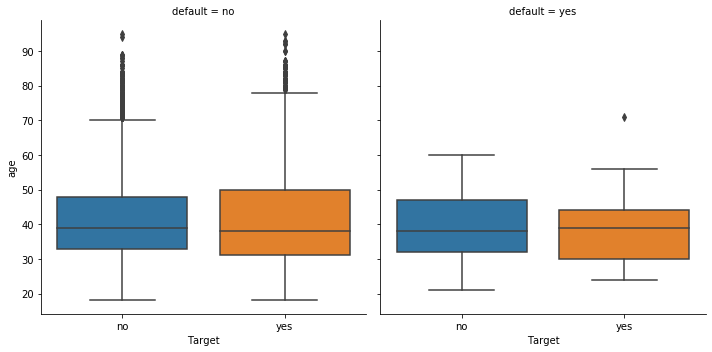

In [25]:
sns.catplot(x='Target', y='age',col='default', data=term_dep, kind='box', aspect=1);

People with less defaults tend to respond better to the campaign

### Pairplot execution for bi-variate analysis

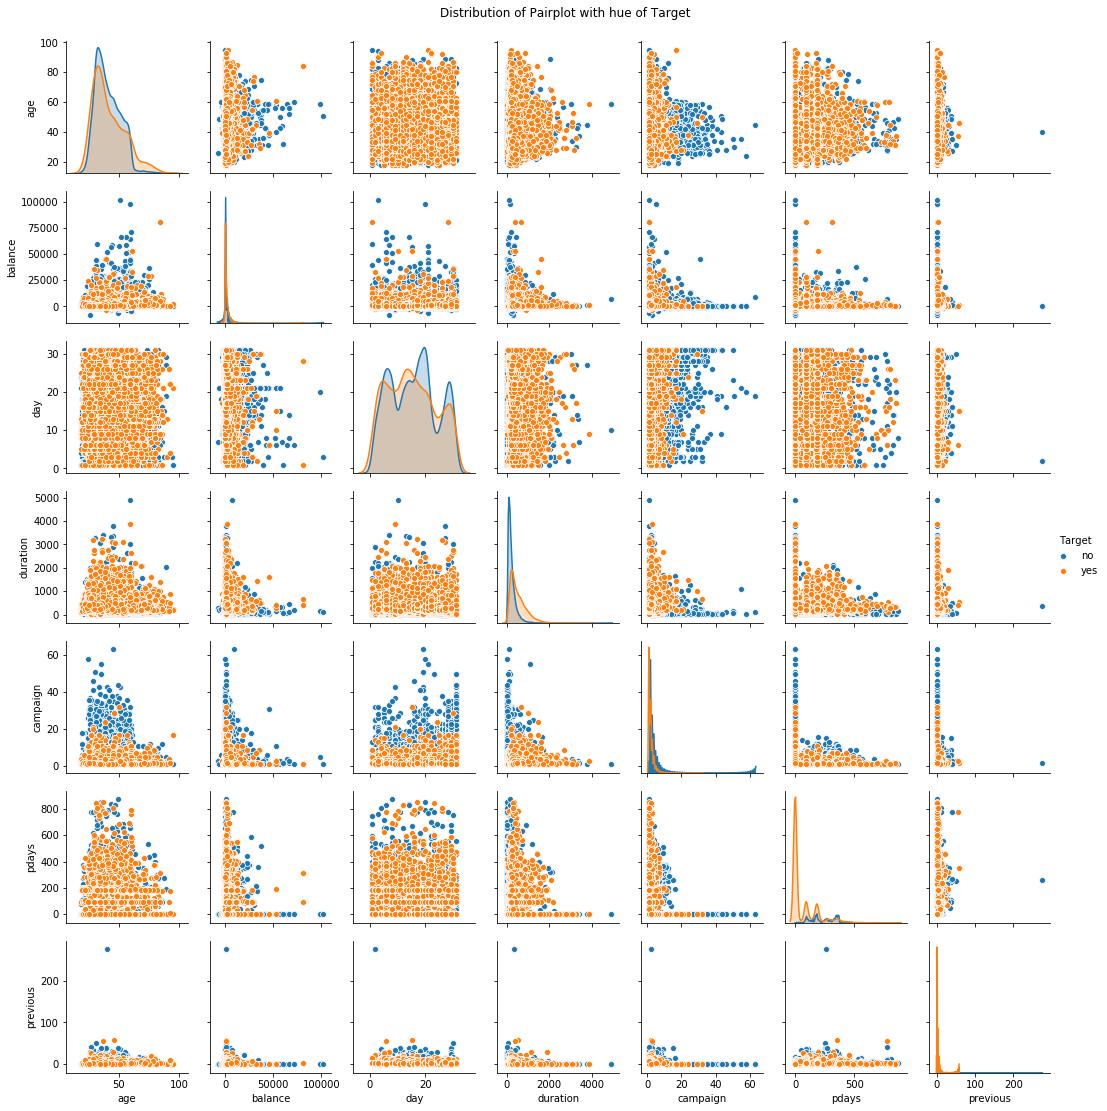

In [26]:
g=sns.pairplot(term_dep, hue='Target',aspect=1)
g.fig.set_size_inches(15,15)
title1='Distribution of Pairplot with hue of Target'
g.fig.suptitle(title1, y=1.02)
print('\n')
plt.show()
print('\n')

Checking relationships between the continuous variable and each of the categorical variables

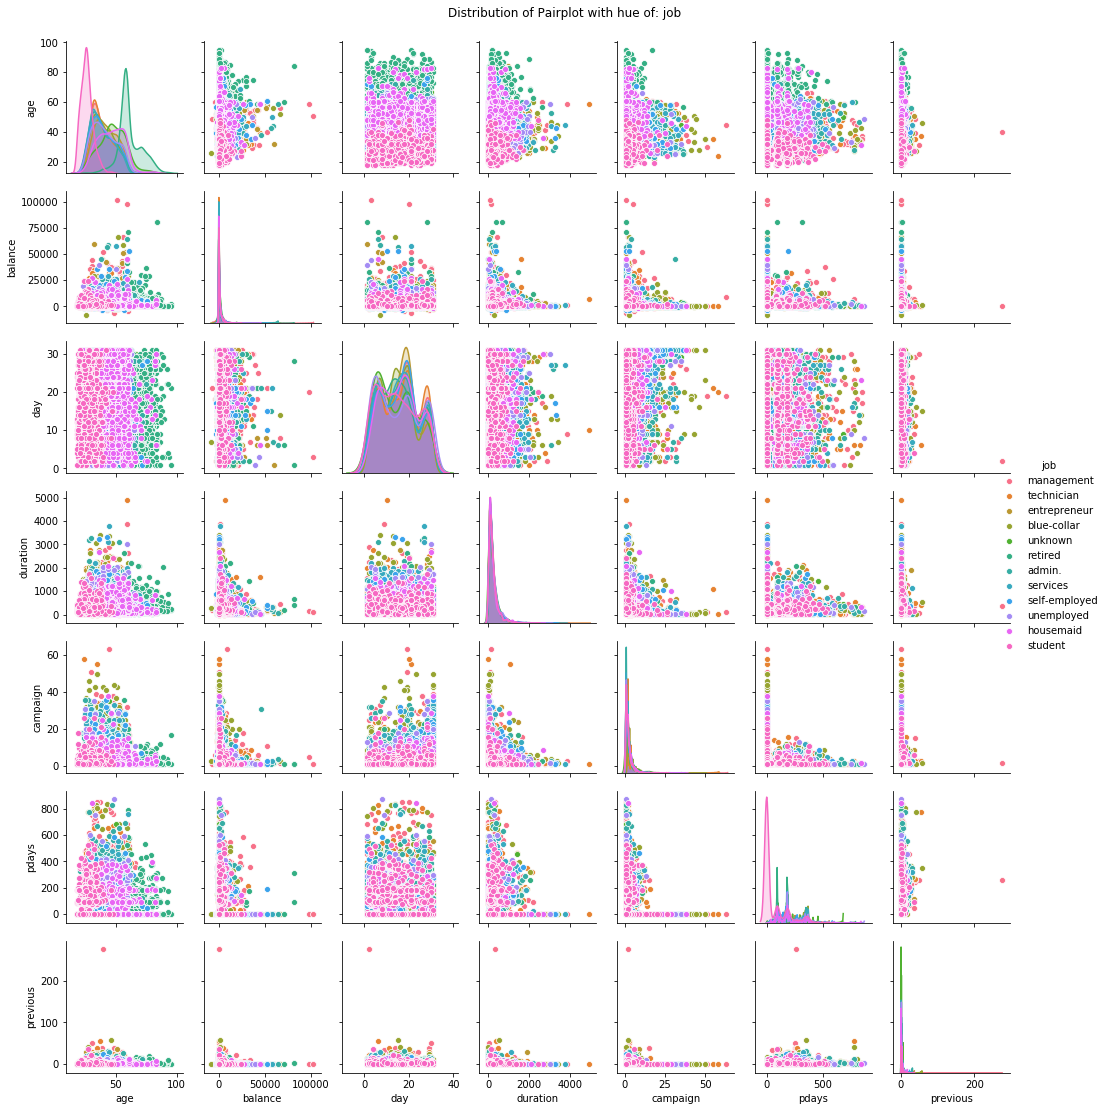

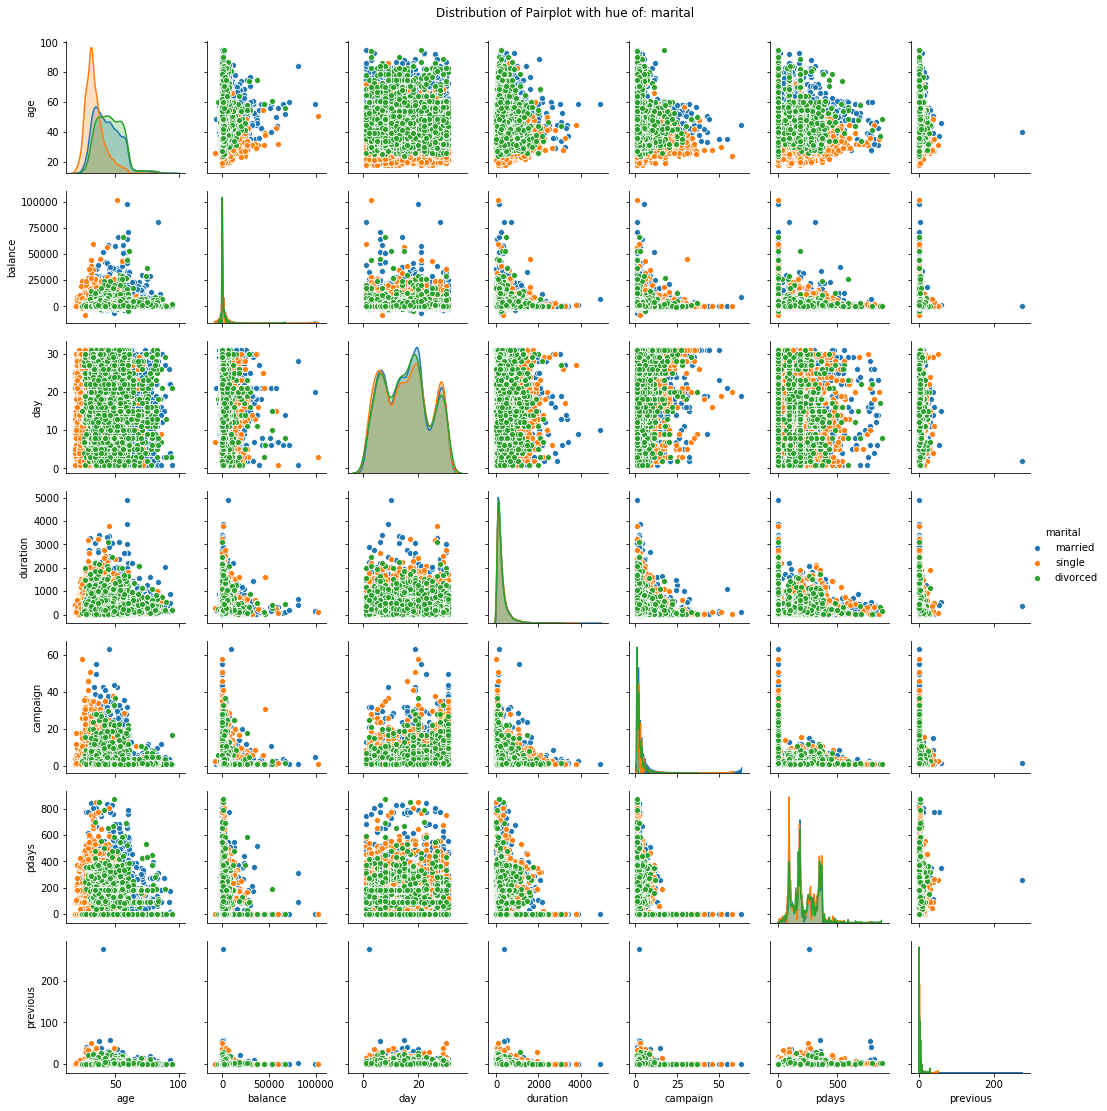

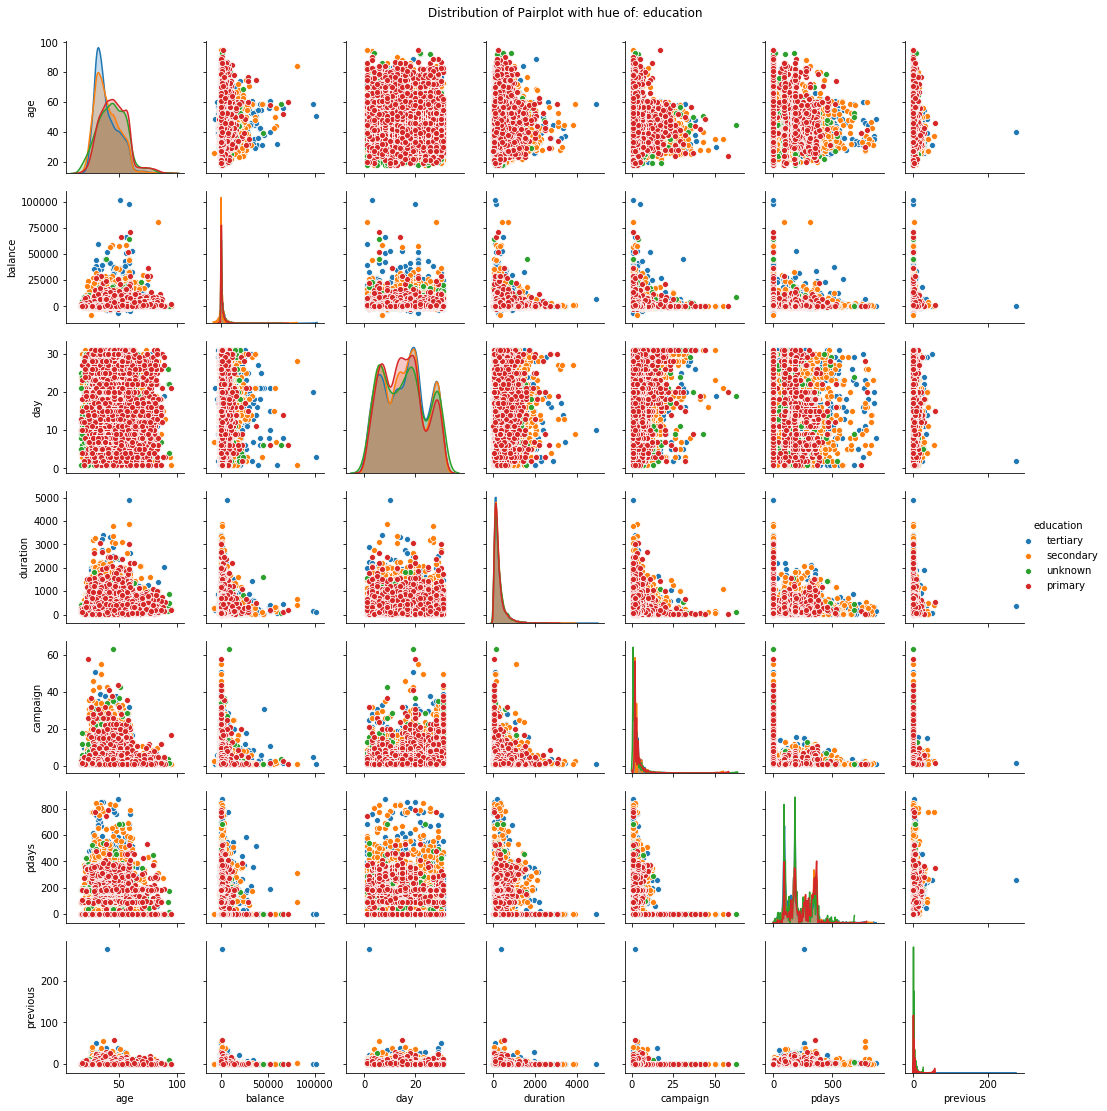

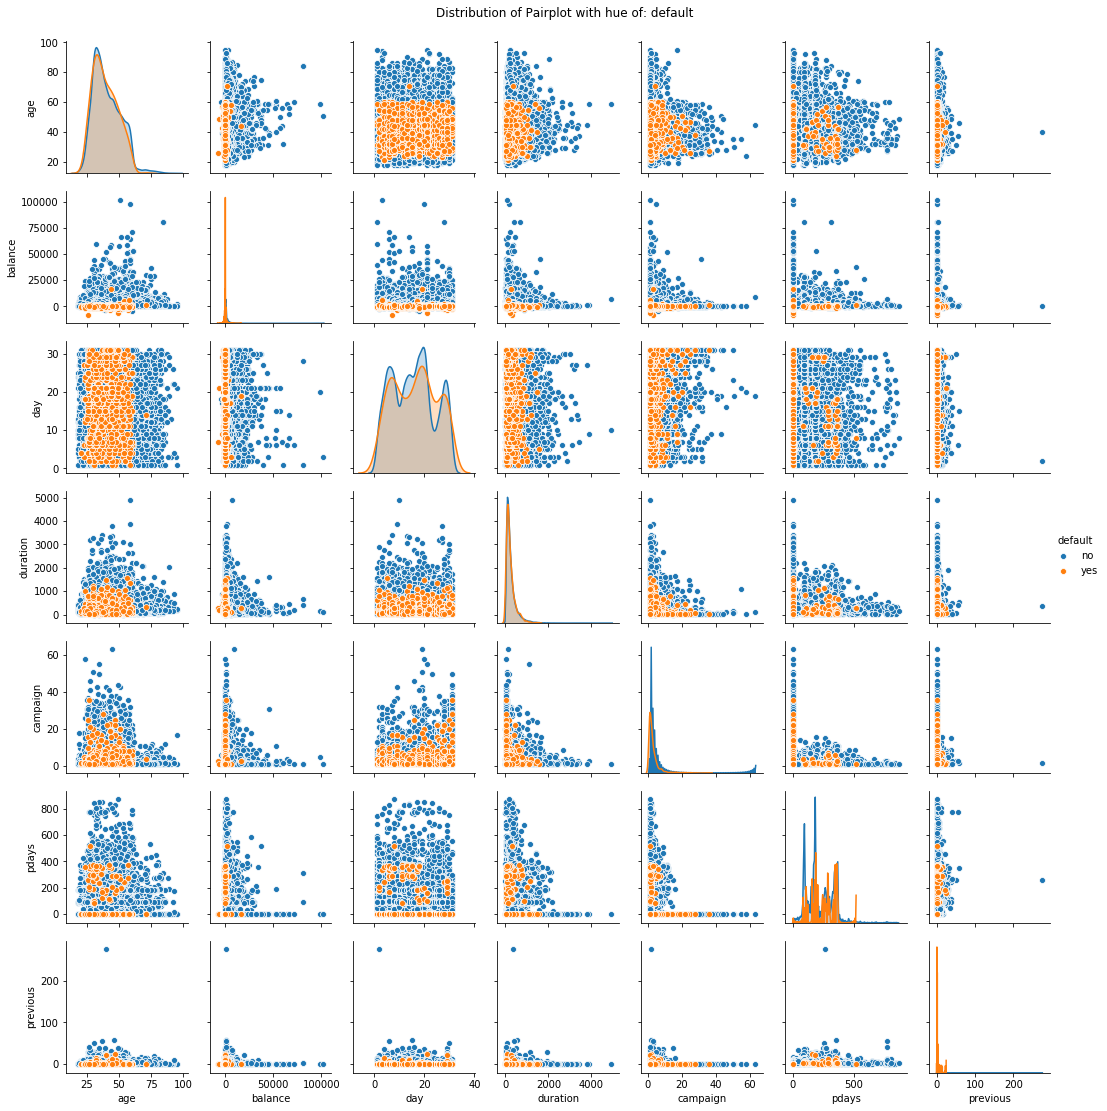

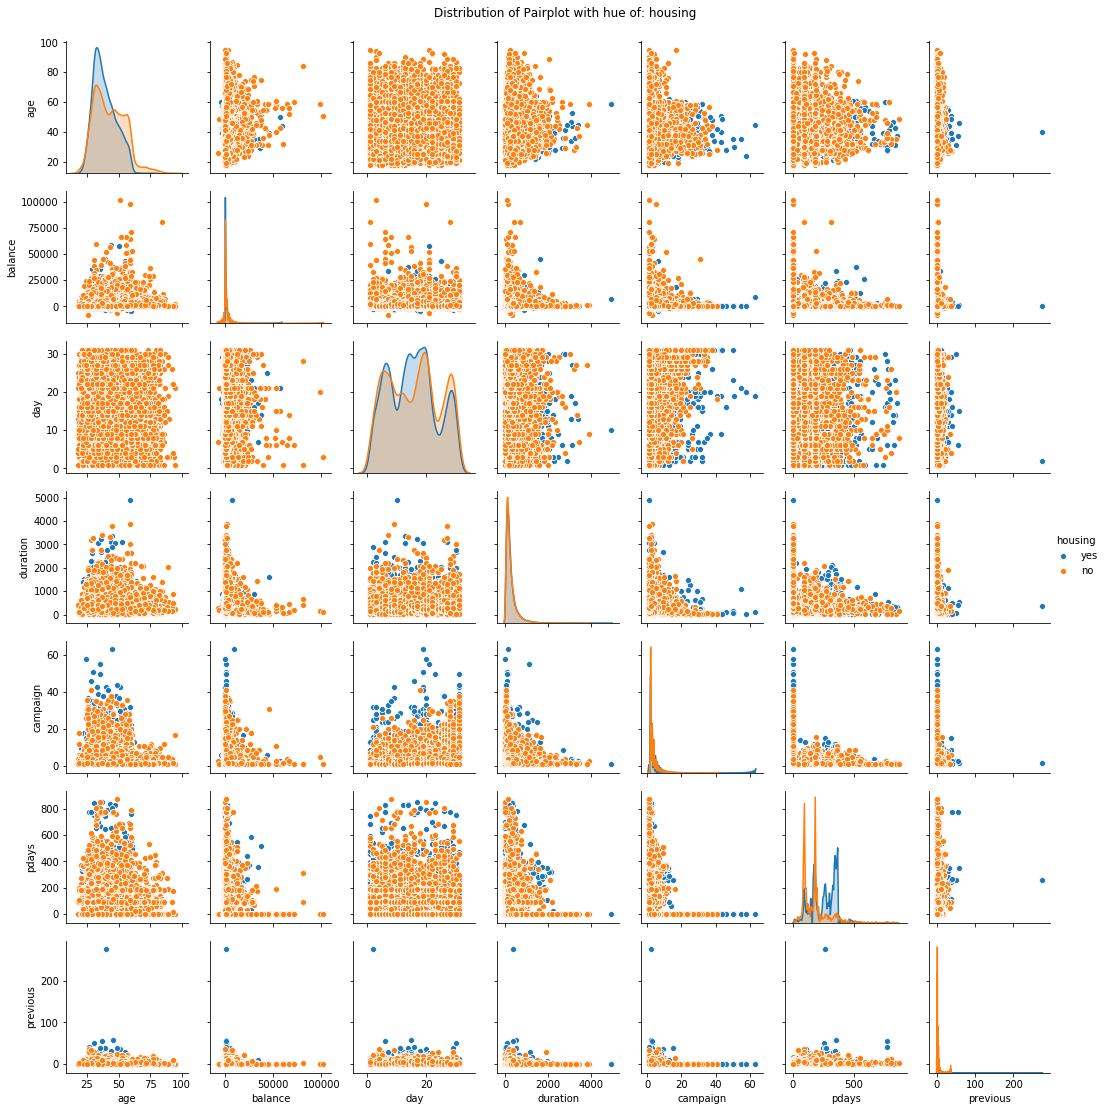

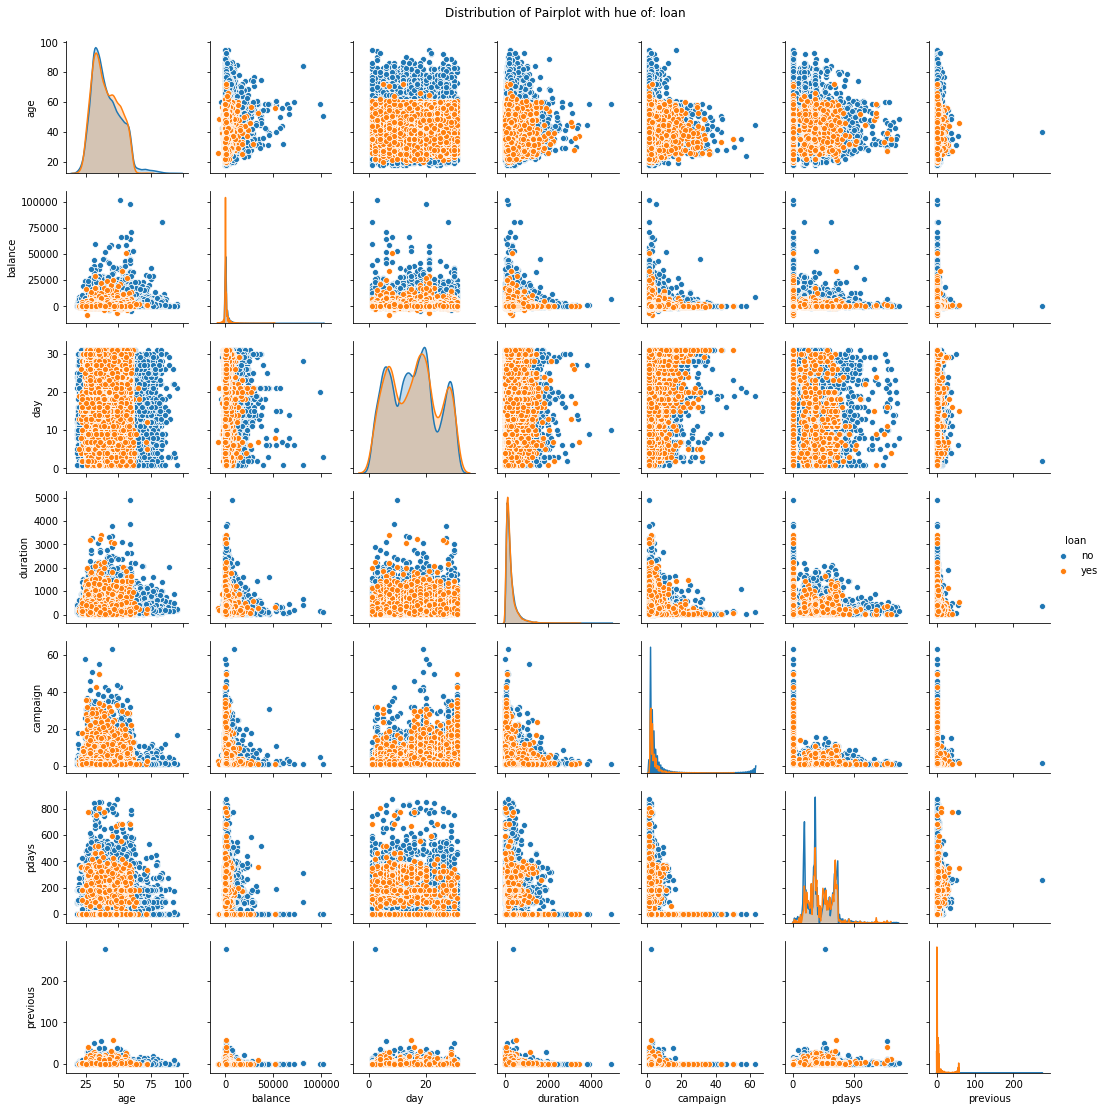

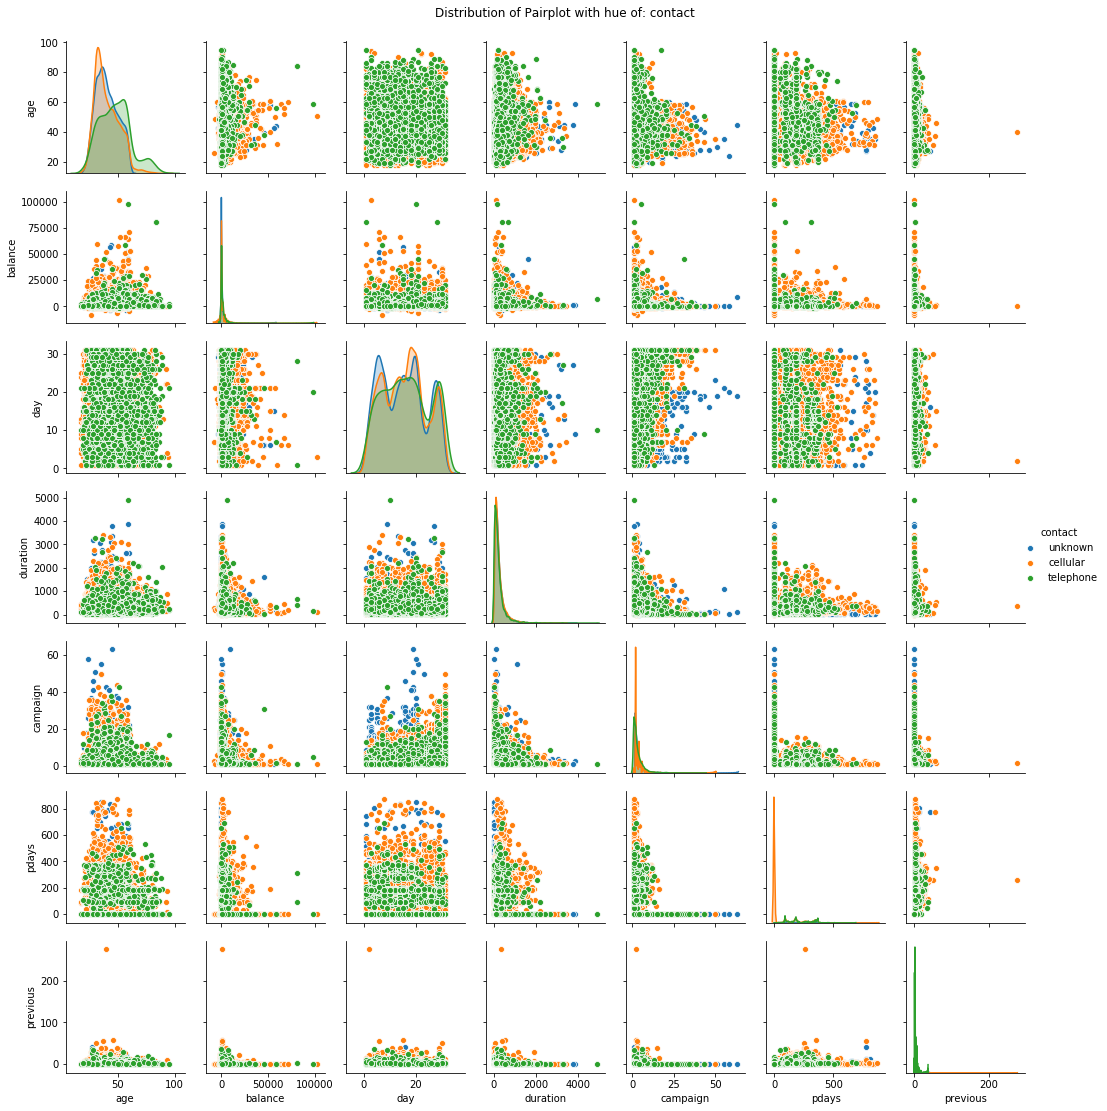

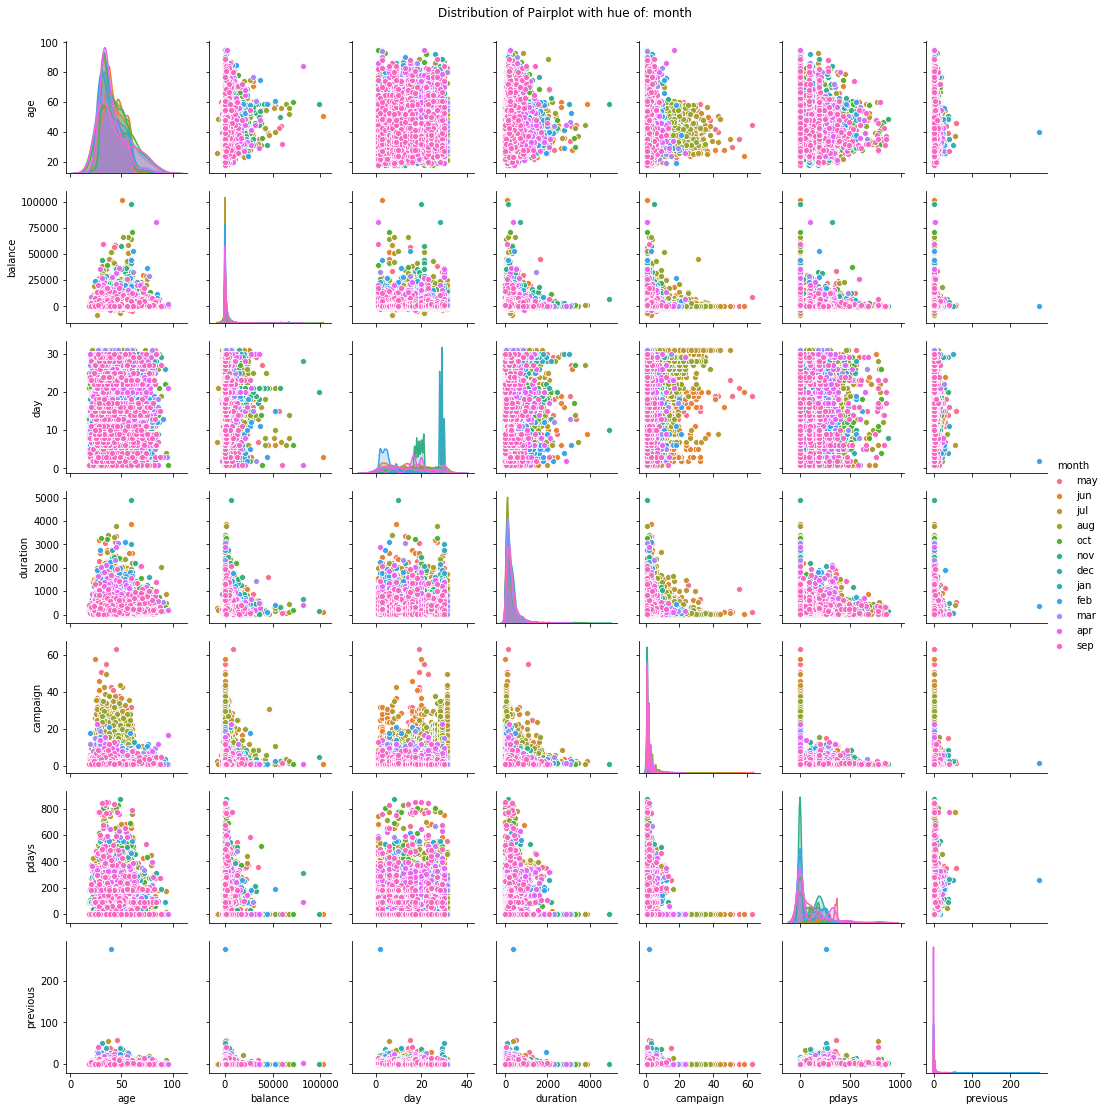

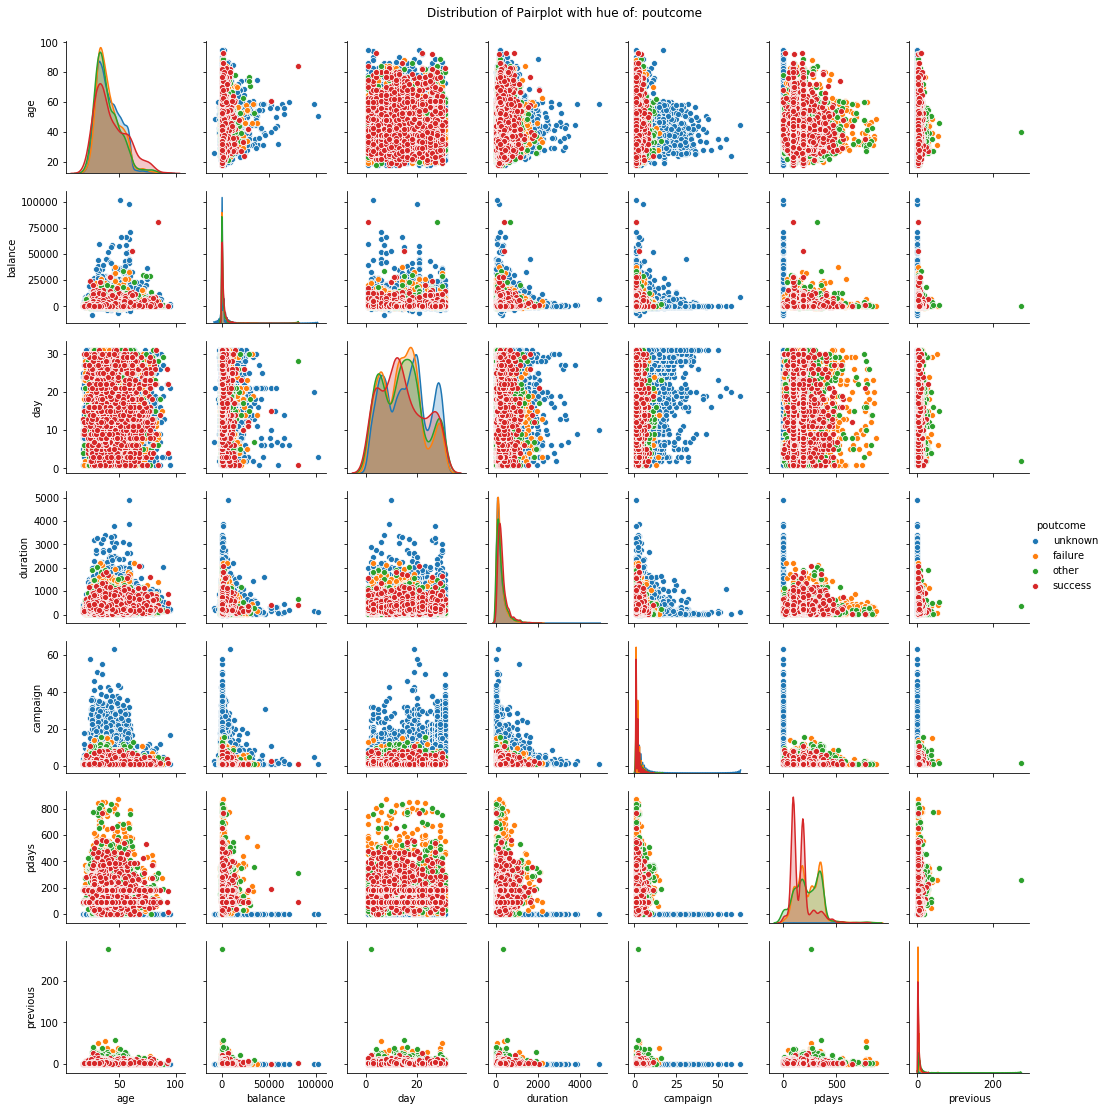

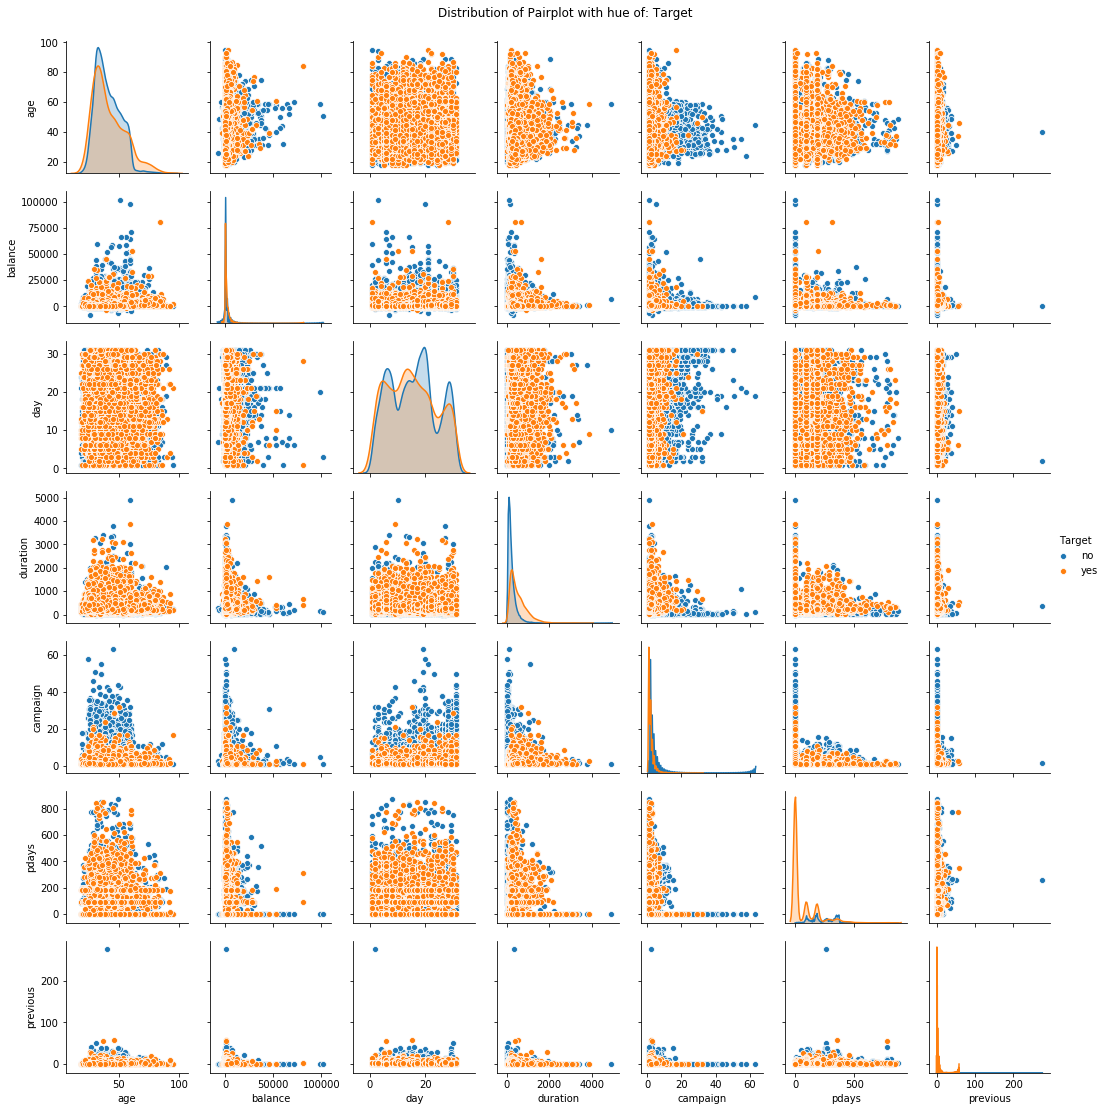

In [60]:
for i in range(0,len(qualparams.columns),1):
    g=sns.pairplot(term_dep, hue=qualparams.columns[i],aspect=1)
    g.fig.set_size_inches(15,15)
    title1='Distribution of Pairplot with hue of: '+qualparams.columns[i]
    g.fig.suptitle(title1, y=1.02)
    print('\n')
    plt.show()
    print('\n')

### Performing Chi-Square test to check relationship with Target

In [28]:

from scipy.stats import chisquare, chi2_contingency
for i in range(len(qualparams.columns)-1):
    print('\033[1m','Chi square test between Target and: ',qualparams.columns[i],'\033[0m')
    ct = pd.crosstab(qualparams[qualparams.columns[i]], qualparams['Target'], normalize='index')
    print('\033[4m','Cross tabulation results','\033[0m')
    print(ct)
    print('\033[4m','Contingency table','\033[0m')
    cc = (chi2_contingency(ct))
    print(cc)
    if (cc[1] < 0.05):
        print('\033[92m','There is a relationship between',qualparams.columns[i] ,'and Target \n', '\033[0m')
    else:
        print('\033[95m','There is no correlation between',qualparams.columns[i] ,'and Target \n', '\033[0m')

 Chi square test between Target and:  job 
 Cross tabulation results 
Target               no       yes
job                              
admin.         0.877973  0.122027
blue-collar    0.927250  0.072750
entrepreneur   0.917283  0.082717
housemaid      0.912097  0.087903
management     0.862444  0.137556
retired        0.772085  0.227915
self-employed  0.881571  0.118429
services       0.911170  0.088830
student        0.713220  0.286780
technician     0.889430  0.110570
unemployed     0.844973  0.155027
unknown        0.881944  0.118056
 Contingency table 
(0.3820913571148449, 0.9999996711720004, 11, array([[0.86595339, 0.13404661],
       [0.86595339, 0.13404661],
       [0.86595339, 0.13404661],
       [0.86595339, 0.13404661],
       [0.86595339, 0.13404661],
       [0.86595339, 0.13404661],
       [0.86595339, 0.13404661],
       [0.86595339, 0.13404661],
       [0.86595339, 0.13404661],
       [0.86595339, 0.13404661],
       [0.86595339, 0.13404661],
       [0.86595339, 0.1340

### Performing two-sample t-test to check relationship with Target

In [29]:
from    scipy.stats import  ttest_ind
import  scipy.stats as  stats 

In [30]:
#Separating targetted success and failure split for t-test
success_target=quantparams[quantparams['Target']=='yes'].copy()
fail_target=quantparams[quantparams['Target']=='no'].copy()

In [31]:
for i in range(len(quantparams.columns)-2):
    print('t-statistic for: ',success_target.columns[i] )
    t_statistic, p_value  =  stats.ttest_ind(success_target[success_target.columns[i]],fail_target[fail_target.columns[i]])
    print('t statistics ',success_target.columns[i],  t_statistic, 'P Value',  p_value ,' \n')
    if(p_value <0.05):
        print(success_target.columns[i], ' has a relationship with Target \n')
    else:
        print(success_target.columns[i], ' does not have a relationship with Target \n')

t-statistic for:  age
t statistics  age 5.350255423036203 P Value 8.825643691922395e-08  

age  has a relationship with Target 

t-statistic for:  balance
t statistics  balance 11.25043445878562 P Value 2.5211136918751468e-29  

balance  has a relationship with Target 

t-statistic for:  day
t statistics  day -6.029843252838383 P Value 1.653880160817521e-09  

day  has a relationship with Target 

t-statistic for:  duration
t statistics  duration 91.28943612670862 P Value 0.0  

duration  has a relationship with Target 

t-statistic for:  campaign
t statistics  campaign -15.599948860003781 P Value 1.0123473642096297e-54  

campaign  has a relationship with Target 

t-statistic for:  pdays
t statistics  pdays 22.087155291232996 P Value 1.5598483528552167e-107  

pdays  has a relationship with Target 



## Train - Test Data Preparation

In [5]:
#Transformation of final data sets prior to modelling
final_table = term_dep.copy()
final_table.shape

(45211, 17)

In [6]:
final_table.drop(['duration'],axis=1)
final_table['age'] = np.where(final_table['age'] > 70, 70, final_table['age'])

In [7]:
#Binning balance into a series
test=pd.DataFrame()
test['Bal_bin']=pd.qcut(final_table['balance'], 10, retbins=False)
new_balance = test['Bal_bin'].value_counts(normalize=True)*100
test['balance']=final_table['balance']
test['next_bal']=test['balance']
test.loc[test.balance <= 102127, 'next_bal'] = 10
test.loc[test.balance <= 3574, 'next_bal'] = 9
test.loc[test.balance <= 1859, 'next_bal'] = 8
test.loc[test.balance <= 1126, 'next_bal'] = 7
test.loc[test.balance <= 70, 'next_bal'] = 6
test.loc[test.balance <= 448, 'next_bal'] = 5
test.loc[test.balance <= 272, 'next_bal'] = 4
test.loc[test.balance <= 131, 'next_bal'] = 3
test.loc[test.balance <= 22, 'next_bal'] =2
test.loc[test.balance <= 0, 'next_bal'] = 1
final_table['new_bal']=test['next_bal']
final_table.drop('balance',axis=1)

,age,job,marital,education,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target,new_bal
0,58,management,married,tertiary,no,yes,no,unknown,5,may,261,1,0,0,unknown,no,9
1,44,technician,single,secondary,no,yes,no,unknown,5,may,151,1,0,0,unknown,no,3
2,33,entrepreneur,married,secondary,no,yes,yes,unknown,5,may,76,1,0,0,unknown,no,2
3,47,blue-collar,married,unknown,no,yes,no,unknown,5,may,92,1,0,0,unknown,no,8
4,33,unknown,single,unknown,no,no,no,unknown,5,may,198,1,0,0,unknown,no,2
5,35,management,married,tertiary,no,yes,no,unknown,5,may,139,1,0,0,unknown,no,4
6,28,management,single,tertiary,no,yes,yes,unknown,5,may,217,1,0,0,unknown,no,5
7,42,entrepreneur,divorced,tertiary,yes,yes,no,unknown,5,may,380,1,0,0,unknown,no,2
8,58,retired,married,primary,no,yes,no,unknown,5,may,50,1,0,0,unknown,no,3
9,43,technician,single,secondary,no,yes,no,unknown,5,may,55,1,0,0,unknown,no,7


In [8]:
#Binning poutcome into a series
pdays1_test = pd.DataFrame()
pdays1_test['pdays']=final_table['pdays']
pdays1_test['pdays_chk'] = pdays1_test.loc[pdays1_test['pdays'] >0, 'pdays']
pdays1_test['pdays_chk']=pd.qcut(pdays1_test['pdays_chk'], 10, retbins=False,duplicates='drop')
pdays1_test['next_pdays']=pdays1_test['pdays']
pdays1_test.loc[pdays1_test.pdays <= 871, 'next_pdays'] = 11
pdays1_test.loc[pdays1_test.pdays <= 362.4, 'next_pdays'] = 10
pdays1_test.loc[pdays1_test.pdays <= 343, 'next_pdays'] = 9
pdays1_test.loc[pdays1_test.pdays <= 300, 'next_pdays'] = 8
pdays1_test.loc[pdays1_test.pdays <= 258, 'next_pdays'] = 7
pdays1_test.loc[pdays1_test.pdays <= 194, 'next_pdays'] = 6
pdays1_test.loc[pdays1_test.pdays <= 181, 'next_pdays'] = 5
pdays1_test.loc[pdays1_test.pdays <= 159, 'next_pdays'] =4
pdays1_test.loc[pdays1_test.pdays <= 108, 'next_pdays'] = 3
pdays1_test.loc[pdays1_test.pdays <= 91, 'next_pdays'] = 2
pdays1_test.loc[pdays1_test.pdays <= 0, 'next_pdays'] = 1
final_table['new_pdays']=pdays1_test['next_pdays']
final_table.drop('pdays',axis=1)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,previous,poutcome,Target,new_bal,new_pdays
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,0,unknown,no,9,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,0,unknown,no,3,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,0,unknown,no,2,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,0,unknown,no,8,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,0,unknown,no,2,1
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,0,unknown,no,4,1
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,0,unknown,no,5,1
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,0,unknown,no,2,1
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,0,unknown,no,3,1
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,0,unknown,no,7,1


In [9]:
# Adding additional column for contact status since it constitutes 80% of the samples
final_table.loc[final_table.previous == 0, 'contact_status'] = 'no'
final_table.loc[final_table.previous >0, 'contact_status'] = 'yes'

In [10]:
from sklearn.model_selection import train_test_split
Master_Data = final_table.copy()
Master_Data=Master_Data.drop('balance',axis=1)
Master_Data=Master_Data.drop('pdays',axis=1)

In [11]:
X_parent = Master_Data.drop(labels = 'Target', axis = 1) #Target is my target variable
Y_parent = Master_Data['Target'] #Extracting target variable
X_parent.shape, Y_parent.shape

((45211, 17), (45211,))

#### Creating dummy variables for analysis

In [12]:
X_parent.dtypes

age                int64
job               object
marital           object
education         object
default           object
housing           object
loan              object
contact           object
day                int64
month             object
duration           int64
campaign           int64
previous           int64
poutcome          object
new_bal            int64
new_pdays          int64
contact_status    object
dtype: object

In [13]:
X_parent = pd.get_dummies(X_parent, drop_first=True)


In [14]:
X_parent.loc[X_parent['contact_status_yes']==1,'contact_status_no']=0
X_parent.loc[X_parent['contact_status_yes']==0,'contact_status_no']=1

#### Normalizing via z-scoring

In [15]:
from scipy.stats import zscore
X_parent_z = X_parent.copy()
X_parent_z.select_dtypes(include=['int64']).apply(zscore)

,age,day,duration,campaign,previous,new_bal,new_pdays
0,1.651055,-1.298476,0.011016,-0.569351,-0.251940,1.158077,-0.409171
1,0.302248,-1.298476,-0.416127,-0.569351,-0.251940,-0.848444,-0.409171
2,-0.757528,-1.298476,-0.707361,-0.569351,-0.251940,-1.182864,-0.409171
3,0.591279,-1.298476,-0.645231,-0.569351,-0.251940,0.823657,-0.409171
4,-0.757528,-1.298476,-0.233620,-0.569351,-0.251940,-1.182864,-0.409171
5,-0.564842,-1.298476,-0.462724,-0.569351,-0.251940,-0.514024,-0.409171
6,-1.239245,-1.298476,-0.159841,-0.569351,-0.251940,-0.179604,-0.409171
7,0.109562,-1.298476,0.473107,-0.569351,-0.251940,-1.182864,-0.409171
8,1.651055,-1.298476,-0.808322,-0.569351,-0.251940,-0.848444,-0.409171
9,0.205905,-1.298476,-0.788906,-0.569351,-0.251940,0.489237,-0.409171


In [16]:
#Getting the test data set for Z-scored data
X=np.array(X_parent_z)
Y=np.array(Y_parent)
X.shape, Y.shape

((45211, 44), (45211,))

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, random_state=3)
unique, counts = np.unique(y_train, return_counts=True)
unique1, counts1 = np.unique(y_test, return_counts=True)
dict(zip(unique, counts)),dict(zip(unique1, counts1))

({'no': 27953, 'yes': 3694}, {'no': 11969, 'yes': 1595})

## Base Model implementation

### K Nearest Neighbours

In [50]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

In [39]:

# Running the KNN algorithm with weights as 'Distance' between 2 and 20 neighbours to identify the best fit based on maximum score
N=[2,3,5,7,8,20]
ka=pd.DataFrame(columns=['Score', 'Neighbours'])
ka[['Score','Neighbours']]=ka[['Score','Neighbours']].astype(int)
i = 0
for i in range(np.size(N)):
    knn = KNeighborsClassifier(n_neighbors= N[i] , weights = 'distance')
    knn.fit(X_train, y_train)    
    predicted_labels = knn.predict(X_test)
    g = f1_score(y_test, predicted_labels, average=None)
    ka.at[i,'Score']=g[1]
    ka.at[i,'Neighbours']=N[i]
Neighbour_max=ka.loc[ka['Score']== ka['Score'].max(), ['Neighbours']]
Score_max=ka.loc[ka['Score']== ka['Score'].max(), ['Score']]
Neighbour_max, Score_max

(   Neighbours
 1         3.0,       Score
 1  0.331105)

In [40]:
knn = KNeighborsClassifier(n_neighbors=3 , weights = 'distance')
model_knn = knn.fit(X_train, y_train) 
predicted_labels = knn.predict(X_test)

In [51]:
from sklearn import metrics
from sklearn.metrics import classification_report,confusion_matrix

In [42]:
print(metrics.confusion_matrix(y_test, predicted_labels))

[[11442   527]
 [ 1174   421]]


In [49]:
print(classification_report(y_test, predicted_labels))


              precision    recall  f1-score   support

          no       0.91      0.96      0.93     11969
         yes       0.44      0.26      0.33      1595

    accuracy                           0.87     13564
   macro avg       0.68      0.61      0.63     13564
weighted avg       0.85      0.87      0.86     13564



Checking if there is any difference using uniform weights

In [43]:
knn1 = KNeighborsClassifier(n_neighbors=3 , weights = 'uniform')
model_knn1 = knn1.fit(X_train, y_train) 
predicted_labels = knn1.predict(X_test)
print(metrics.confusion_matrix(y_test, predicted_labels))
print(classification_report(y_test, predicted_labels))

[[11442   527]
 [ 1178   417]]
              precision    recall  f1-score   support

          no       0.91      0.96      0.93     11969
         yes       0.44      0.26      0.33      1595

    accuracy                           0.87     13564
   macro avg       0.67      0.61      0.63     13564
weighted avg       0.85      0.87      0.86     13564



### Logistic Regression

#### Logistic Regression without Hyperparameter Tuning

In [44]:
from sklearn.linear_model import LogisticRegression
model_logreg=LogisticRegression(solver='newton-cg',max_iter=1000,class_weight='balanced')
model_logreg.fit(X_train, y_train)
y_pred=model_logreg.predict(X_test)
cr = metrics.classification_report(y_test, y_pred)
print(metrics.classification_report(y_test, y_pred),'\n')


              precision    recall  f1-score   support

          no       0.97      0.85      0.91     11969
         yes       0.42      0.82      0.55      1595

    accuracy                           0.85     13564
   macro avg       0.70      0.83      0.73     13564
weighted avg       0.91      0.85      0.87     13564
 



#### Logistic Regression with Hyperparameter Tuning

In [ ]:
max_iter1 = [500, 750, 1000, 1250, 1500, 1750, 2000,6000]
solver1= ['lbfgs', 'liblinear', 'sag', 'saga']
recall=0
for i in range(np.size(max_iter1)):
    for j in range(np.size(solver1)):
        model_logreg1=LogisticRegression(max_iter=max_iter1[i],solver=solver1[j],class_weight='balanced')
        model_logreg1.fit(X_train, y_train)
        y_pred=model_logreg1.predict(X_test)
        print('For max_iter1 =',max_iter1[i], 'and solver =',solver1[j],':')
        print(metrics.classification_report(y_test, y_pred),'\n')    

Hence, we see that saga fails to converge meaningfully with horrendous f1-scores for 'Yes' values
newton-cg and liblinear converges within 1000 iterations while the lbfg solver converges at 1750 iterations. Sag solvers take almost 6000 iterations to converge. However, the saga solver does not converge even after 6000 iterations

 The max precision we get is 0.42 and recall of 0.82 with a f1-score of 0.55. In this case, recall is more important since false positives will not be an issue. However, missing potential targets given the limited information would be more critical

In [53]:
y_train1=np.array(y_train)
y_train1[y_train == 'yes'] = 1
y_train1[y_train == 'no'] = 0
y_train1 = y_train1.astype(int)
y_train1

array([1, 0, 0, ..., 0, 1, 0])

In [54]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train1)


C:\Users\Swami\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='warn', n_jobs=None, penalty='l2',
                   random_state=None, solver='warn', tol=0.0001, verbose=0,
                   warm_start=False)

In [55]:
# np.exp(model_logreg.coef_)
import statsmodels.api as sm
logit = sm.Logit(y_train1, sm.add_constant(X_train))
lg = logit.fit()

lgcoef = pd.DataFrame(lg.params, columns=['coef'])
lgcoef.loc[:, "Odds_ratio"] = np.exp(lgcoef.coef)
lgcoef['probability'] = lgcoef['Odds_ratio']/(1+lgcoef['Odds_ratio'])
lgcoef['pval']=lg.pvalues
pd.options.display.float_format = '{:.2f}'.format
lgcoef = lgcoef.sort_values(by="Odds_ratio", ascending=False)
lgcoef
      

Optimization terminated successfully.
         Current function value: 0.240140
         Iterations 9


C:\Users\Swami\Anaconda3\lib\site-packages\statsmodels\base\model.py:1286: RuntimeWarning: invalid value encountered in sqrt
  bse_ = np.sqrt(np.diag(self.cov_params()))
C:\Users\Swami\Anaconda3\lib\site-packages\scipy\stats\_distn_infrastructure.py:877: RuntimeWarning: invalid value encountered in greater
  return (self.a < x) & (x < self.b)
C:\Users\Swami\Anaconda3\lib\site-packages\scipy\stats\_distn_infrastructure.py:877: RuntimeWarning: invalid value encountered in less
  return (self.a < x) & (x < self.b)
C:\Users\Swami\Anaconda3\lib\site-packages\scipy\stats\_distn_infrastructure.py:1831: RuntimeWarning: invalid value encountered in less_equal
  cond2 = cond0 & (x <= self.a)


,coef,Odds_ratio,probability,pval
41,2.24,9.37,0.90,0.00
35,1.47,4.35,0.81,0.00
38,0.93,2.53,0.72,0.00
42,0.82,2.28,0.70,0.46
39,0.70,2.01,0.67,0.00
30,0.59,1.80,0.64,0.01
34,0.51,1.67,0.63,0.00
15,0.32,1.38,0.58,0.01
23,0.26,1.29,0.56,0.04
22,0.25,1.28,0.56,0.01


In [56]:
ev_od=[41, 35, 38, 42, 39]
print('Top 5 Odds-Ratio come from')
for i in range(np.size(ev_od)):
    print(X_parent_z.columns[ev_od[i]])

Top 5 Odds-Ratio come from
poutcome_unknown
month_may
month_sep
contact_status_yes
poutcome_other


In [57]:
print("Classification Report :\n")
print(metrics.classification_report(y_test, y_pred))
print("Confusion Matrix :\n")
cm = metrics.confusion_matrix(y_test, y_pred)
print(metrics.confusion_matrix(y_test, y_pred))

Classification Report :

              precision    recall  f1-score   support

          no       0.97      0.83      0.89     11969
         yes       0.38      0.79      0.51      1595

    accuracy                           0.82     13564
   macro avg       0.67      0.81      0.70     13564
weighted avg       0.90      0.82      0.85     13564

Confusion Matrix :

[[9881 2088]
 [ 338 1257]]


### Naive Bayes Classifier

In [58]:
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
model_NB = GaussianNB()
model_NB.fit(X_train, y_train)
print(model_NB)
predicted = model_NB.predict(X_test)

GaussianNB(priors=None, var_smoothing=1e-09)


In [59]:
print("Classification Report :\n")
print(metrics.classification_report(y_test, predicted))
print("Confusion Matrix :\n")
print(metrics.confusion_matrix(y_test, predicted))

Classification Report :

              precision    recall  f1-score   support

          no       0.93      0.90      0.92     11969
         yes       0.41      0.51      0.45      1595

    accuracy                           0.85     13564
   macro avg       0.67      0.71      0.68     13564
weighted avg       0.87      0.85      0.86     13564

Confusion Matrix :

[[10776  1193]
 [  779   816]]


### Support Vector Machines

In [48]:
from sklearn import svm

#### SVM without hyperparameter tuning

In [63]:
model_svm = svm.SVC()
model_svm.fit(X_train , y_train)
y_pred = model_svm.predict(X_test)
print('Classification Report')
print(metrics.classification_report(y_test, y_pred))

C:\Users\Swami\Anaconda3\lib\site-packages\sklearn\svm\base.py:193: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


Classification Report
              precision    recall  f1-score   support

          no       0.89      0.99      0.94     11969
         yes       0.50      0.07      0.12      1595

    accuracy                           0.88     13564
   macro avg       0.69      0.53      0.53     13564
weighted avg       0.84      0.88      0.84     13564



#### SVM with hyperparameter tuning

In [46]:
c=[2**-15, 2**-5, 2**-2,2**0, 2**2]
gamma=[2**-7, 2**-5,2**-3,2**1, 2**3]

In [49]:
for i in range(np.size(c)):
    for j in range(np.size(gamma)):
        model_svm = svm.SVC(gamma=gamma[j],C=c[i])
        model_svm.fit(X_train , y_train)
        y_pred = model_svm.predict(X_test)
        print('Classification Report for gamma=',gamma[j],'and c=',c[i])
        print(metrics.classification_report(y_test, y_pred))

Classification Report for gamma= 0.0078125 and c= 3.0517578125e-05


C:\Users\Swami\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1437: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)


              precision    recall  f1-score   support

          no       0.88      1.00      0.94     11969
         yes       0.00      0.00      0.00      1595

    accuracy                           0.88     13564
   macro avg       0.44      0.50      0.47     13564
weighted avg       0.78      0.88      0.83     13564

Classification Report for gamma= 0.03125 and c= 3.0517578125e-05


C:\Users\Swami\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1437: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)


              precision    recall  f1-score   support

          no       0.88      1.00      0.94     11969
         yes       0.00      0.00      0.00      1595

    accuracy                           0.88     13564
   macro avg       0.44      0.50      0.47     13564
weighted avg       0.78      0.88      0.83     13564

Classification Report for gamma= 0.125 and c= 3.0517578125e-05


...

C:\Users\Swami\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1437: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)


              precision    recall  f1-score   support

          no       0.88      1.00      0.94     11969
         yes       0.00      0.00      0.00      1595

    accuracy                           0.88     13564
   macro avg       0.44      0.50      0.47     13564
weighted avg       0.78      0.88      0.83     13564

Classification Report for gamma= 2 and c= 0.03125


C:\Users\Swami\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1437: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)


              precision    recall  f1-score   support

          no       0.88      1.00      0.94     11969
         yes       0.00      0.00      0.00      1595

    accuracy                           0.88     13564
   macro avg       0.44      0.50      0.47     13564
weighted avg       0.78      0.88      0.83     13564



KeyboardInterrupt: 

### Decision Trees

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(criterion = 'entropy', class_weight='balanced' )
dt_model.fit(X_train , y_train)

In [ ]:
dt_model.score(X_train , y_train)
y_pred = dt_model.predict(X_test)

In [ ]:
print("Classification Report :\n")
print(metrics.classification_report(y_test, y_pred))

In [ ]:
print("Confusion Matrix :\n")
print(metrics.confusion_matrix(y_test, y_pred))

### Ensemble Models

#### Random Forest

In [52]:
from sklearn.ensemble import RandomForestClassifier
n_est=[20, 50, 60, 70, 80, 90, 100, 150, 200]
for i in range(np.size(n_est)):
    model_ranfor = RandomForestClassifier(n_estimators=n_est[i], random_state=3)
    model_ranfor.fit(X_train, y_train)
    y_pred = model_ranfor.predict(X_test)
    print("Classification Report for :", n_est[i])
    print(metrics.classification_report(y_test, y_pred))

Classification Report for : 20
              precision    recall  f1-score   support

          no       0.92      0.98      0.95     11969
         yes       0.66      0.33      0.44      1595

    accuracy                           0.90     13564
   macro avg       0.79      0.66      0.69     13564
weighted avg       0.89      0.90      0.89     13564

Classification Report for : 50
              precision    recall  f1-score   support

          no       0.92      0.98      0.95     11969
         yes       0.68      0.39      0.49      1595

    accuracy                           0.91     13564
   macro avg       0.80      0.68      0.72     13564
weighted avg       0.89      0.91      0.90     13564

Classification Report for : 60
              precision    recall  f1-score   support

          no       0.92      0.98      0.95     11969
         yes       0.68      0.39      0.49      1595

    accuracy                           0.91     13564
   macro avg       0.80      0.68  

We get a relatively low recall score of a maximum of 0.4 at around 200 iterations

#### Gradient Boost

In [53]:
from sklearn.ensemble import GradientBoostingClassifier

#### Gradient Boost without Tuning the Hyperparameters

In [55]:
model_gb = GradientBoostingClassifier()
model_gb.fit(X_train, y_train)
print('Learning rate: ',learning_rate1[i])
print('Score')
print(model_gb.score(X_train, y_train))
print(metrics.classification_report(y_test, y_pred),'\n')

Learning rate:  10.0
Score
0.9107656333933706
              precision    recall  f1-score   support

          no       0.92      0.97      0.95     11969
         yes       0.67      0.40      0.50      1595

    accuracy                           0.91     13564
   macro avg       0.79      0.68      0.72     13564
weighted avg       0.89      0.91      0.89     13564
 



#### Gradient Boost withTuning the Learning rate

In [54]:
learning_rate1=np.array([0.05, 0.075, 0.1, 0.25, 0.5, 0.75, 1,2,4,10])
for i in range(np.size(learning_rate1)):
    model_gb = GradientBoostingClassifier(n_estimators=20, learning_rate=learning_rate1[i], max_features=2, max_depth=2, random_state=0)
    model_gb.fit(X_train, y_train)
    print('Learning rate: ',learning_rate1[i])
    print('Score')
    print(model_gb.score(X_train, y_train))
    print(metrics.classification_report(y_test, y_pred),'\n')

Learning rate:  0.05
Score
0.8832748759756059
              precision    recall  f1-score   support

          no       0.92      0.97      0.95     11969
         yes       0.67      0.40      0.50      1595

    accuracy                           0.91     13564
   macro avg       0.79      0.68      0.72     13564
weighted avg       0.89      0.91      0.89     13564
 

Learning rate:  0.075
Score
0.8832748759756059
              precision    recall  f1-score   support

          no       0.92      0.97      0.95     11969
         yes       0.67      0.40      0.50      1595

    accuracy                           0.91     13564
   macro avg       0.79      0.68      0.72     13564
weighted avg       0.89      0.91      0.89     13564
 

Learning rate:  0.1
Score
0.883559263121307
              precision    recall  f1-score   support

          no       0.92      0.97      0.95     11969
         yes       0.67      0.40      0.50      1595

    accuracy                           0.

Again, Gradient Boost does not provide a better recall value maxing out at 0.40

### XG Boost Classifier

#### XG Boost without tuning the Hyperparameters

In [56]:
#Will need to install the XG Boost using 'conda install -c anaconda py-xgboost' from Anaconda prompt
from xgboost import XGBClassifier
model_XGB = XGBClassifier()
model_XGB.fit(X_train, y_train)
y_pred = model_XGB.predict(X_test)
print('Classification Report:')
print(metrics.classification_report(y_test, predicted_labels))

Classification Report:
              precision    recall  f1-score   support

          no       0.91      0.96      0.93     11969
         yes       0.44      0.26      0.33      1595

    accuracy                           0.87     13564
   macro avg       0.67      0.61      0.63     13564
weighted avg       0.85      0.87      0.86     13564



#### XG Boost with tuning the Hyperparameters

In [ ]:
max_depth1 = [5,10,15, 100]
learning_rate1 = [0.1, 0.4, 0.8]
n_estimators1 =  [100, 200, 600, 1000]
for i in range(np.size(max_depth1)):
    for j in range(np.size(learning_rate1)):
        for k in range(np.size(n_estimators1)):
            model_XGB = XGBClassifier(max_depth=max_depth1[i],learning_rate=learning_rate1[j],n_estimators=n_estimators1[k])
            model_XGB.fit(X_train, y_train)
            y_pred = model_XGB.predict(X_test)
            print('Classification Report for max_depth=',max_depth1[i], 'and learning rate =',learning_rate1[j], 'and n_estimators =',n_estimators1[k])
            print(metrics.classification_report(y_test, predicted_labels))

Classification Report for max_depth= 5 and learning rate = 0.1 and n_estimators = 100
              precision    recall  f1-score   support

          no       0.91      0.96      0.93     11969
         yes       0.44      0.26      0.33      1595

    accuracy                           0.87     13564
   macro avg       0.67      0.61      0.63     13564
weighted avg       0.85      0.87      0.86     13564

Classification Report for max_depth= 5 and learning rate = 0.1 and n_estimators = 200
              precision    recall  f1-score   support

          no       0.91      0.96      0.93     11969
         yes       0.44      0.26      0.33      1595

    accuracy                           0.87     13564
   macro avg       0.67      0.61      0.63     13564
weighted avg       0.85      0.87      0.86     13564

Classification Report for max_depth= 5 and learning rate = 0.1 and n_estimators = 600
              precision    recall  f1-score   support

          no       0.91      0.96

Classification Report for max_depth= 10 and learning rate = 0.8 and n_estimators = 100
              precision    recall  f1-score   support

          no       0.91      0.96      0.93     11969
         yes       0.44      0.26      0.33      1595

    accuracy                           0.87     13564
   macro avg       0.67      0.61      0.63     13564
weighted avg       0.85      0.87      0.86     13564

Classification Report for max_depth= 10 and learning rate = 0.8 and n_estimators = 200
              precision    recall  f1-score   support

          no       0.91      0.96      0.93     11969
         yes       0.44      0.26      0.33      1595

    accuracy                           0.87     13564
   macro avg       0.67      0.61      0.63     13564
weighted avg       0.85      0.87      0.86     13564

Classification Report for max_depth= 10 and learning rate = 0.8 and n_estimators = 600
              precision    recall  f1-score   support

          no       0.91      0

There seems to be no change in the Gradient Boost which gives us a score of 0.26  as recall independent of whether we balance the class_weights or not. Also changing the hyperparameters hasn't made any impact

### Hypertuning the Random Forest Model using Grid Search

We will be hypertuning the main parameters for the Random Forest classifier. These include the n_estimators which will basically help us define the number of trees in the forest. We will use three values here: 100 trees, 200 trees and 500 trees.

We will also define the number of features that will be used for this analysis. This will be derived from the number of features in the training set: auto which will use max_features as the square root of number of features in the training set and log 2 which will use log2(number of features in the training set) features

Further, we will also define the max_depth parameter in a range of 4-8. this will ensure we reduce the overfitting of the model as well as ensure that there is some regularization of the model (i.e. not overtly impacted by outliers

Finally, we will define the criteria for the model to describe the mode / quality of the split. We will use the gini and the entropy models for the Grid Search

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier(random_state=3,class_weight='balanced')
param = { 
    'n_estimators': [100, 200, 500],
    'max_features': ['auto', 'log2'],
    'max_depth' : [4,5,6,7,8],
    'criterion' :['gini', 'entropy']
}
clf_grid = GridSearchCV(estimator=rfc, param_grid=param, cv= 5)
clf_grid.fit(X_train, y_train)

GridSearchCV(cv=5, error_score='raise-deprecating',
             estimator=RandomForestClassifier(bootstrap=True,
                                              class_weight='balanced',
                                              criterion='gini', max_depth=None,
                                              max_features='auto',
                                              max_leaf_nodes=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              n_estimators='warn', n_jobs=None,
                                              oob_score=False, random_state=3,
                                              verbose=0, warm_start=False),
             

In [30]:
print('The best parameters for the Random Forest model is: ',clf_grid.best_params_)
print('The best score for the Random Forest model is: ',clf_grid.best_score_)

The best parameters for the Random Forest model is:  {'criterion': 'gini', 'max_depth': 8, 'max_features': 'log2', 'n_estimators': 100}
The best score for the Random Forest model is:  0.8404904098334756


In [26]:
import math
error1 = 1-clf_grid.best_score_
t2=1.96*math.sqrt((error1 * (1 - error1)) / 45211)
upper_bound = error1+t2
lower_bound = error1-t2
if lower_bound<0:
    lower_bound=0
print("There is a 95% likelihood that the confidence interval [",lower_bound,' - ',upper_bound,'] covers the true classification error of the model')

There is a 95% likelihood that the confidence interval [ 0.1561344345950895  -  0.16288474573795939 ] covers the true classification error of the model


### The range estimate at 95% confidence is [ 0.156  -  0.163 ] 